In [1]:
from ADAPT_VQE.Methods import ADAPT_minimization, Quantum_ADAPT_minimization, ADAPT_mixed_minimization
from ADAPT_VQE.Circuit import Circuits_Composser
from qibo import  set_backend
import io

import numpy as np

from tqdm import tqdm
import contextlib

set_backend("qibojit")

f = io.StringIO()

[Qibo 0.2.21|INFO|2026-08-03 20:21:48]: Using qibojit (numba) backend on /CPU:0


In [2]:
nuc='Be6'
ref_state=0
shell='p'

data, nucleus = ADAPT_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=1, threshold=1e-5)


 --------------------------------------------------------------------------
                            ADAPT for  Be6
 --------------------------------------------------------------------------

Initial Energy:  1.5679

------------ LAYER 1 ------------
Operator: [0, 3, 4, 5] , Gradient: -7.527717371155747
Energy:  -0.8882113101563893
Rel. Error:  0.7086683621340153
Theta: 0.5781652643034633

Operators used for each layer:
Layer 0: Operator [0, 3, 4, 5], Theta = 0.5781652643034633, Gradient = -7.527717371155747

 Final energy result: -0.8882113101563893	 Final relative error is 0.7086683621340153
Number of energy measurements: 11


In [3]:
used_operators = data['used_operators']
thetas = data['parameters']


composer = Circuits_Composser(nucleus='Be6',
                              shell='p',
                              ref_state=0,
                              parameters=thetas,
                              operators_used=used_operators,
                              exact=True) 


Et_exact = composer.Qibo_measure_Energy()


print(Et_exact)

(0.54649+0j)|000011> + (0.83747+0j)|100100>
Energy,			observable,		amplitude

1.14320133 		 0 		 1.63
1.14320133 		 3 		 1.63
0.67793435 		 4 		 2.27
0.67793435 		 5 		 2.27
-1.18675519 		 [0, 3, 0, 3] 		 -1.6921
0.10145123 		 [4, 5, 4, 5] 		 0.3397
-3.4451787 		 [0, 3, 4, 5] 		 -3.76385869

-----------------------------------Final Energies-----------------------------------

Monoparticular energies:                  3.642271349707024
Two body energies with 2 diferent index:  -1.0853039622384968
Two body energies with 3 diferent index:  0.0
Two body energies with 4 diferent index:  -3.4451786976246743
-0.8882113101561475


In [4]:
data_mixed, nucleo = ADAPT_mixed_minimization(data = data, nucleus = nucleus, ref_state = ref_state, max_layers = 2, exact = False, max_executions = 100, nshots=500, threshold=5e-2)

 --------------------------------------------------------------------------
                            ADAPT for  Be6
 --------------------------------------------------------------------------



Initial Energy:  1.518409061030754

------------ LAYER 0 ------------
Operator: [0, 3, 4, 5]
Energy:  1.518409061030754
Rel. Error:  1.4980353139420781
Theta: 0.45

------------ LAYER 1 ------------
Operator: [0, 3, 4, 5]
Energy:  -0.562060718410339
Rel. Error:  0.8156451423189094
New operator:  [0, 3, 4, 5]     Theta: 0.45

Operators used for each layer:
Layer 1: Operator [0, 3, 4, 5], Theta = 0.45

 Final energy result: -0.562060718410339	 Final relative error is 0.8156451423189094
Number of energy measurements: 22


In [6]:
shell = 'p'
nuc='Be6'
ref_state=0

data, nucleus = Quantum_ADAPT_minimization(nucleus=nuc, ref_state = ref_state, shell=shell, max_layers=2, exact=True, max_executions=350)

 --------------------------------------------------------------------------
                            ADAPT for  Be6
 --------------------------------------------------------------------------

Initial Energy:  1.5679

------------ LAYER 1 ------------
Operator: [0, 3, 4, 5] , Gradient: -7.527717371155745
Energy:  -0.8882113101565392
Rel. Error:  0.708668362133966
Theta: 0.5781652705870356

------------ LAYER 2 ------------
Operator: [0, 3, 1, 2] , Gradient: 4.908336145768413
Energy:  -3.039440063251015
Rel. Error:  0.003069380340922009
Theta: -0.7502683070756513

Operators used for each layer:
Layer 0: Operator [0, 3, 4, 5], Theta = 0.6111263800158271, Gradient = -7.527717371155745
Layer 1: Operator [0, 3, 1, 2], Theta = -0.7502683070756513, Gradient = 4.908336145768413

 Final energy result: -3.039440063251015	 Final relative error is 0.003069380340922009
Number of energy measurements: 276


In [6]:
used_operators = data['used_operators']
thetas = data['parameters']


composer = Circuits_Composser(nucleus='He6',
                              shell='p',
                              ref_state=0,
                              parameters=thetas,
                              operators_used=used_operators,
                              exact=True) 


Qibo_circuits = composer.Qibo_all_circuits()


Et_exact = composer.Qibo_measure_energy_no_diagonalization_4_index()

print(Et_exact)

(0.57379+0j)|000011> + (-0.55842+0j)|011000> + (0.59911+0j)|100100>
Energy,			observable,		amplitude

0.5850507 		 0 		 1.63
0.50829569 		 1 		 1.63
0.50829569 		 2 		 1.63
0.5850507 		 3 		 1.63
0.74736423 		 4 		 2.27
0.74736423 		 5 		 2.27
-0.60734006 		 [6, 9, 6, 9] 		 -1.6921
-0.52766082 		 [7, 8, 7, 8] 		 -1.6921
0.11184125 		 [10, 11, 10, 11] 		 0.3397
-0.69794838 		 [6, 9, 7, 8] 		 1.0431
-2.5877331 		 [6, 9, 10, 11] 		 -3.76385869
-2.4120202 		 [7, 8, 10, 11] 		 3.76385869

-----------------------------------Final Energies-----------------------------------

Monoparticular energies:                  3.681421241202254
Two body energies with 2 diferent index:  -1.0231596266603489
Two body energies with 3 diferent index:  0.0
Two body energies with 4 diferent index:  -5.697701680532417
-3.0394400659905125


In [7]:
composer = Circuits_Composser(nucleus='He6',
                              shell='p',
                              ref_state=0,
                              parameters=thetas,
                              operators_used=used_operators,
                              exact=False,
                              nshots=500)
 
Et_shots = composer.Qibo_measure_Energy()
print(Et_shots)

Energy,			observable,		amplitude

0.61614 		 6 		 1.63
0.4564 		 7 		 1.63
0.4564 		 8 		 1.63
0.61614 		 9 		 1.63
0.77634 		 10 		 2.27
0.77634 		 11 		 2.27
-0.6396138 		 [6, 9, 6, 9] 		 -1.6921
-0.473788 		 [7, 8, 7, 8] 		 -1.6921
0.1161774 		 [10, 11, 10, 11] 		 0.3397
-0.6905322 		 [6, 9, 7, 8] 		 1.0431
0.013233 		 [6, 9, 7, 11] 		 -1.10275
0.0022055 		 [6, 9, 8, 10] 		 -1.10275
-2.58200706 		 [6, 9, 10, 11] 		 -3.76385869
-2.35617554 		 [7, 8, 10, 11] 		 3.76385869
0.004411 		 [7, 8, 11] 		 -1.10275
0.0242605 		 [8, 7, 10] 		 -1.10275

-----------------------------------Final Energies-----------------------------------

Monoparticular energies:                  3.6977600000000006
Two body energies with 2 diferent index:  -0.9972243999999999
Two body energies with 3 diferent index:  0.028671500000000023
Two body energies with 4 diferent index:  -5.613276295478169
-2.884069195478168


In [8]:

list_shots=[500, 1000, 2500]

desviaciones_fixed=[]
medias_fixed=[]
for shots in list_shots:
    composer.nshots = shots
    energies=[]
    print('----------------',shots,'----------------')
    for _ in tqdm(range(100), leave=False, desc="Repeticiones"):
        with contextlib.redirect_stdout(f):
            Et_shots = composer.Qibo_measure_Energy()
        energies.append(Et_shots)
    desviaciones_fixed.append(np.std(energies))
    medias_fixed.append(np.mean(energies))
    print('DONE')
    
    

---------------- 500 ----------------


DONE
---------------- 1000 ----------------


DONE
---------------- 2500 ----------------


DONE


In [9]:
list_shots=[500, 1000, 2500]
results={}
k=0
with open("Convergence_data/He6_Fermionic_2_layer.dat", "w") as file:
    file.write("shots theta1_mean theta1_std theta2_mean theta2_std energy_mean energy_std energy_mean_fixed energy_std_fixed\n")
    
    for shots in list_shots:
        
        fixed_E=medias_fixed[k]
        fiexd_std=desviaciones_fixed[k]
        thetas_1=[]
        thetas_2=[]
        energias=[]
        print('--------------', shots, ' shots --------------')
        for _ in tqdm(range(20), leave=False, desc="Repeticiones"):
            with contextlib.redirect_stdout(f):       
                data_mix, nucleo = ADAPT_mixed_minimization(data=data, nucleus=nucleus, ref_state = ref_state, max_layers=5, exact=False, nshots=shots)
            thetas_1.append(data_mix['parameters'][0])
            thetas_2.append(data_mix['parameters'][1])

            energias.append(data_mix['Energy'])
            
        print('DONE')
        results[shots] = {'theta_1': [np.mean(thetas_1), np.std(thetas_1)], 'theta_2':[np.mean(thetas_2), np.std(thetas_2)],  'energy':[np.mean(energias), np.std(energias)]}
        
        media_t1, std_t1 = results[shots]['theta_1']
        media_t2, std_t2 = results[shots]['theta_2']

        media_E, std_E = results[shots]['energy']
        
        
        file.write(f"{shots} {media_t1:.6f} {std_t1:.6f} {media_t2:.6f} {std_t2:.6f} {media_E:.6f} {std_E:.6f} {fixed_E:.6f} {fiexd_std:.6f}\n")
        
        k += 1


-------------- 500  shots --------------


DONE
-------------- 1000  shots --------------


DONE
-------------- 2500  shots --------------


DONE


# QUASIPARTICLE

In [7]:
from QP_ADAPT_VQE.Methods import QP_ADAPT_minimization, QP_ADAPT_mixed_minimization, QP_Quantum_ADAPT_minimization
from QP_ADAPT_VQE.Circuit import QP_Circuits_Composser
from qibo import  set_backend
import io

import numpy as np

from tqdm import tqdm
import contextlib

set_backend("qibojit")

f = io.StringIO()

[Qibo 0.2.21|INFO|2026-08-03 20:22:35]: Using qibojit (numba) backend on /CPU:0


In [9]:
shell='p'
nuc='Be6'
ref_state=0

data_c, nucleus = QP_ADAPT_minimization(nuc, ref_state = ref_state, shell=shell, max_layers=10, threshold=1e-10)

 --------------------------------------------------------------------------
                            ADAPT for  Be6
 --------------------------------------------------------------------------

Initial Energy:  1.5679

------------ LAYER 1 ------------
Operator: 0 2 , Gradient: 7.527717371155747
Energy:  -0.8882113101563893
Rel. Error:  0.708668362134015
Theta: 0.5781652643034633

------------ LAYER 2 ------------
Operator: 0 1 , Gradient: -4.908336127500618
Energy:  -3.041562722612797
Rel. Error:  0.0023731520657033264
Theta: -0.7764791017555596

------------ LAYER 3 ------------
Operator: 0 2 , Gradient: 0.43352964357053514
Energy:  -3.0487945879525036
Rel. Error:  1.1138466988940835e-06
Theta: 0.012329095402607185

------------ LAYER 3 ------------
Operator: 0 1 , Gradient: -0.007165750250052345
Energy:  -3.0487945879525036
Rel. Error:  1.1138466988940835e-06
Theta: 0.0

------------ LAYER 4 ------------
Operator: 0 1 , Gradient: -0.007165750250052345
Energy:  -3.0487945879525036


In [10]:
shell='p'
nuc='Be6'
ref_state=0

data_mixed, nucleus = QP_ADAPT_mixed_minimization(data = data_c, nucleus = nucleus, ref_state = ref_state, max_layers = 10, exact = False, nshots=1000, threshold=1e-5, max_executions=2000)

 --------------------------------------------------------------------------
                            ADAPT for  Be6
 --------------------------------------------------------------------------

Initial Energy:  1.5679

------------ LAYER 1 ------------
Operator: 0 2
Energy:  -0.8878179955465759
Rel. Error:  0.7087973685857043
Theta: 0.585

------------ LAYER 2 ------------
Operator: 0 1
Energy:  -3.0132431074894956
Rel. Error:  0.01166193252060774
Theta: -0.6929699085294381

------------ LAYER 3 ------------
Operator: 0 2
Energy:  -2.9647685835051734
Rel. Error:  0.027561485144678762
Theta: -0.011329276208699236

------------ LAYER 3 ------------
Operator: 0 1
Energy:  -2.9647685835051734
Rel. Error:  0.027561485144678762
Theta: -0.01705114818231306

------------ LAYER 4 ------------
Operator: 0 1
Energy:  -3.048346241895408
Rel. Error:  0.00014817050951190116
New operator:  0 1     Theta: -0.01705114818231306

Operators used for each layer:
Layer 1: Operator 02, Theta = 0.6208208542

In [11]:
shell='p'
nuc='Be6'
ref_state=0

data_c, nucleus = QP_Quantum_ADAPT_minimization(nuc, ref_state = ref_state, shell=shell, max_layers=10, threshold=5e-3, max_executions=10000)

 --------------------------------------------------------------------------
                            ADAPT for  Be6
 --------------------------------------------------------------------------

Initial Energy:  1.5679

------------ LAYER 1 ------------
Operator: 0 2 , Gradient: -5.907417655445738
Energy:  -0.8882113101563744
Rel. Error:  0.70866836213402
Theta: 0.5781652636938178

------------ LAYER 2 ------------
Operator: 0 1 , Gradient: 6.862547268493181
Energy:  -3.039440117004574
Rel. Error:  0.0030693627098554214
Theta: -0.750268345882054

Operators used for each layer:
Layer 0: Operator 0,2, Theta = 0.6111262856589513, Gradient = -5.907417655445738
Layer 1: Operator 0,1, Theta = -0.750268345882054, Gradient = 6.862547268493181

 Final energy result: -3.039440117004574	 Final relative error is 0.0030693627098554214
Number of energy measurements: 44


## Roto

In [3]:
from QP_ADAPT_VQE.Methods import QP_Roto_minimization, QP_Quantum_Roto_minimization
from QP_ADAPT_VQE.Circuit import QP_Circuits_Composser
from qibo import  set_backend
import io

import numpy as np

from tqdm import tqdm
import contextlib

set_backend("qibojit")

f = io.StringIO()

[Qibo 0.2.18|INFO|2026-07-01 01:47:51]: Using qibojit (numba) backend on /CPU:0


In [10]:
shell = 'p'
nuc = 'He8'
ref_state=0

data, nucleus = QP_Roto_minimization(nuc, ref_state = ref_state, shell = shell, max_layers=3, threshold=1e-9)

 --------------------------------------------------------------------------
                            ADAPT for  He8
 --------------------------------------------------------------------------

Initial Energy:  0.5397999999999996
-1.6322226130325215 [np.float64(-0.5233910757350716)]

------------ LAYER 1 ------------
Operator: 1 2
Energy:  -1.6322226130325215
Rel. Error:  0.5171563086626669
Theta: -0.5233910757350716
-3.2987319508259145 [np.float64(-0.5233910757350716), np.float64(0.47150297798225915)]

------------ LAYER 2 ------------
Operator: 0 2
Energy:  -3.2987319508259145
Rel. Error:  0.02416992685209725
Theta: 0.47150297798225915
-3.3724345193889365 [np.float64(-0.5233910757350716), np.float64(0.47150297798225915), np.float64(0.09198237728046482)]

------------ LAYER 3 ------------
Operator: 1 2
Energy:  -3.3724345193889365
Rel. Error:  0.0023672511742402307
Theta: 0.09198237728046482

Operators used for each layer:
Layer 0: Operator 1,2, Theta = -0.5233910757350716
Layer 1: 

In [12]:
test = QP_Circuits_Composser('He8',shell='p', parameters=data['parameters'], operators_used=data['used_operators'], exact=True)

test.Qibo_measure_Energy()

(0.39342+0j)|011> + (-0.42683+0j)|101> + (0.81427+0j)|110>


(np.float64(-3.372434519388936),
 np.float64(2.0056903079487003),
 np.float64(-5.378124827337633),
 <qibo.result.QuantumState at 0x2c08c6f3c50>)

In [18]:
test.Qibo_all_circuits()[1].execute().probabilities()

array([7.62173113e-02, 8.98210408e-02, 3.33957179e-01, 4.46843706e-06,
       4.46843706e-06, 3.33957179e-01, 8.98210408e-02, 7.62173113e-02])

In [17]:
shell = 'sd'
nuc='O18'
ref_state=0

data_q, nucleus = QP_Quantum_Roto_minimization(nuc, ref_state = ref_state, shell=shell, max_layers=4, threshold=5e-3, exact=False, nshots=2000)

 --------------------------------------------------------------------------
                            ADAPT for  O18
 --------------------------------------------------------------------------

Initial Energy:  -9.3151
-9.81427876186133 [np.float64(-0.6274300794843954)]

------------ LAYER 1 ------------
Operator: 0 1
Energy:  -9.81427876186133
Rel. Error:  0.17746790716161728
Theta: -0.6274300794843954
-10.479172380887992 [np.float64(-0.6274300794843954), np.float64(0.6056544205964046)]

------------ LAYER 2 ------------
Operator: 0 3
Energy:  -10.479172380887992
Rel. Error:  0.12174334978526202
Theta: 0.6056544205964046
-11.166506040558634 [np.float64(-0.6274300794843954), np.float64(0.6056544205964046), np.float64(0.7966457927041413)]

------------ LAYER 3 ------------
Operator: 0 2
Energy:  -11.166506040558634
Rel. Error:  0.0641380985706597
Theta: 0.7966457927041413
-11.519530377539361 [np.float64(-0.6274300794843954), np.float64(0.6056544205964046), np.float64(0.796645792704141

## Roto ADAPT

In [18]:
from QP_ADAPT_VQE.Methods import QP_Roto_ADAPT_minimization, QP_Quantum_Roto_ADAPT_minimization
from QP_ADAPT_VQE.Circuit import QP_Circuits_Composser
from qibo import  set_backend
import io
from tqdm import tqdm
import contextlib



set_backend("qibojit")

f = io.StringIO()

[Qibo 0.2.21|INFO|2026-06-24 13:37:23]: Using qibojit (numba) backend on /CPU:0


In [19]:
shell='sd'
nuc='Be6'
ref_state=0

data_q, nucleus = QP_Roto_ADAPT_minimization(nuc, ref_state = ref_state, shell=shell, max_layers=3, threshold=5e-3)

 --------------------------------------------------------------------------
                            ADAPT for  Be6
 --------------------------------------------------------------------------

Initial Energy:  1.5679

------------ LAYER 1 ------------
Operator: 0 2
Energy:  -0.888211310174134
Rel. Error:  0.7086683621281948
Theta: [np.float64(0.5781667432057257)]

------------ LAYER 2 ------------
Operator: 0 1
Energy:  -3.0468302114212453
Rel. Error:  0.0006454256514384718
Theta: [np.float64(0.5781667432057257), np.float64(-0.7853981633974723)]

Operators used for each layer:
Layer 0: Operator 0,2, Theta = 0.5781667432057257
Layer 1: Operator 0,1, Theta = -0.7853981633974723

 Final energy result: -3.0468302114212453	 Final relative error is 0.0006454256514384718
[np.float64(1.5679), np.float64(-0.888211310174134), np.float64(-3.0468302114212453)]
Number of energy measurements: 31


In [20]:
print(len(nucleus.ops_hop))

3


In [21]:
shell='sd'
nuc='O18'
ref_state=0

data_q, nucleus = QP_Quantum_Roto_ADAPT_minimization(nuc, ref_state = ref_state, shell=shell, max_layers=2, threshold=5e-3, exact=True)

 --------------------------------------------------------------------------
                            ADAPT for  O18
 --------------------------------------------------------------------------

Initial Energy:  -9.3151

------------ LAYER 1 ------------
Operator: 0 1
Energy:  -9.814428280677731
Rel. Error:  0.1774553760293805
Theta: [np.float64(-0.6265697347947239)]

------------ LAYER 2 ------------
Operator: 0 3
Energy:  -10.485162090310581
Rel. Error:  0.12155530526765036
Theta: [np.float64(-0.5859932828222147), np.float64(0.5994028166316697)]

Operators used for each layer:
Layer 0: Operator 0,1, Theta = -0.5859932828222147
Layer 1: Operator 0,3, Theta = 0.5994028166316697

 Final energy result: -10.485162090310581	 Final relative error is 0.12124135383157035
[np.float64(-9.3151), np.float64(-9.814428280677731), np.float64(-10.485162090310581)]
Number of energy measurements: 85


## Convergence TESTS p shell

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# --- AÑADIR ESTE BLOQUE DE CONSTANTES DE COLOR ---
COL_STD  = "#4A6FA5"  # Azul acero (Standard/Different circuits)
COL_REC  = "#C0392B"  # Rojo ladrillo (Reconstructed)
COL_DIAG = "#5F6A6A"  # Gris azulado (Diagonal)
COL_REF  = "black"    # Líneas de referencia

# Configuración de estilo
plt.rcParams.update({"text.usetex": False,"font.family": "serif","font.size": 12,"axes.grid": True,"grid.alpha": 0.3})

# Constantes de referencia


def run_monte_carlo_analysis(experiment_func, n_experiments, VALOR_CALCULADO, VALOR_GS_EXACTO, VALOR_DIAG_REF, VALOR_HOP_REF, save = False):
    
    diag_values = []
    hop_raw_values = []
    hop_rec_values = []
    total_rec_values = [] 
    total_values = []
    
    print(f"Simulando {n_experiments} experimentos...")
    
    for _ in tqdm(range(n_experiments)):
        # Simulación de datos
        E_t_sim, E_diag_sim, E_hop, _ = experiment_func()
        
        diag_values.append(E_diag_sim)
        hop_rec_values.append(E_t_sim - E_diag_sim)
        total_rec_values.append(E_t_sim)
        
        # Simulación Raw
        total_values.append(E_diag_sim + E_hop)
        hop_raw_values.append(E_hop)

    # Conversión a arrays
    diag_values = np.array(diag_values)
    hop_rec_values = np.array(hop_rec_values)
    hop_raw_values = np.array(hop_raw_values)
    total_rec_values = np.array(total_rec_values)
    total_values = np.array(total_values)

    # --- FIGURA 1: Desglose por Términos (Sin cambios) ---
    # 1. Definir "Bin Width" común para coherencia física
    # Calculamos el rango de ambas y tomamos una referencia (ej. 50 bins para la más ancha)
    span_diag = np.max(diag_values) - np.min(diag_values)
    span_hop = np.max(hop_raw_values) - np.min(hop_raw_values)
    
    # Usamos el span mayor para definir la resolución
    max_span = max(span_diag, span_hop)
    bin_width = max_span / 50  # Definimos el grosor del bin aquí
    
    # Generamos los bins explícitos para cada lado usando ese width constante
    # Esto asegura que una barra tenga el mismo ancho visual en ambos lados
    bins_diag = np.arange(np.min(diag_values), np.max(diag_values) + bin_width, bin_width)
    bins_hop  = np.arange(np.min(hop_raw_values), np.max(hop_raw_values) + bin_width, bin_width)

    # 2. Configurar el "Broken Axis" (2 subplots lado a lado)
    # sharey=True para que la altura sea comparable
    fig, (ax_hop, ax_diag) = plt.subplots(1, 2, sharey=True, figsize=(10, 4.5))
    
    # Ajustar espacio entre plots (muy pequeño para simular corte)
    plt.subplots_adjust(wspace=0.05) 

    # --- IZQUIERDA: Hopping Term (Negativo) ---
    ax_hop.hist(hop_raw_values, bins=bins_hop, color=COL_STD, alpha=1, 
                label='Diferent circuits', density=True)
    ax_hop.hist(hop_rec_values, bins=bins_hop, color=COL_REC, alpha=0.85, 
                label='Reconstructed Z-basis', density=True)
    ax_hop.axvline(VALOR_HOP_REF, color=COL_REF, linestyle='--', linewidth=1.5, 
                   label='Statevector Hopping')
    
    # --- DERECHA: Diagonal Term (Positivo) ---
    ax_diag.hist(diag_values, bins=bins_diag, color=COL_DIAG, alpha=0.9, 
                 label='Diagonal terms', density=True)
    ax_diag.axvline(VALOR_DIAG_REF, color=COL_REF, linestyle='--', linewidth=1.5, 
                    label='Statevector diagonal')

    # 3. Forzar la MISMA escala visual en X (mismo zoom level)
    # Calculamos el centro de cada distribución
    mid_hop = np.mean(hop_raw_values)
    mid_diag = np.mean(diag_values)
    
    # Definimos una ventana de visualización común (la más ancha de las dos + margen)
    common_window_half_width = max(span_diag, span_hop) * 0.6 # un poco más del 50%
    
    ax_hop.set_xlim(mid_hop - common_window_half_width, mid_hop + common_window_half_width)
    ax_diag.set_xlim(mid_diag - common_window_half_width, mid_diag + common_window_half_width)

    # 4. Estética de "Eje Roto"
    # Ocultar la espina derecha del plot izquierdo y la izquierda del derecho
    ax_hop.spines['right'].set_visible(False)
    ax_diag.spines['left'].set_visible(False)
    
    # Quitar ticks del eje Y en el lado derecho (ya que comparten escala)
    ax_diag.tick_params(axis='y', left=False) 
    
    # Añadir marcas de ruptura (diagonales)
    d = .015  # tamaño de la marca diagonal
    kwargs = dict(transform=ax_hop.transAxes, color='k', clip_on=False)
    # Líneas de ruptura en eje superior e inferior del plot izquierdo
    ax_hop.plot((1-d, 1+d), (-d, +d), **kwargs)
    ax_hop.plot((1-d, 1+d), (1-d, 1+d), **kwargs)
    
    

    kwargs.update(transform=ax_diag.transAxes)  # cambiar al plot derecho
    # Líneas de ruptura en eje superior e inferior del plot derecho
    ax_diag.plot((-d, +d), (-d, +d), **kwargs)
    ax_diag.plot((-d, +d), (1-d, 1+d), **kwargs)

    # Etiquetas y Títulos
    ax_hop.set_ylabel('Probability Density')
    ax_hop.set_xlabel('Energy (MeV)')
    ax_diag.set_xlabel('Energy (MeV)') # Poner label en ambos o solo centrado
    
    ax_hop.set_title(r'Hopping terms', loc='left')
    ax_diag.set_title(r'    Diagonal terms', loc='left')
    
    # Leyendas (puedes unificarlas si quieres, aquí las dejo separadas por claridad)
    ax_hop.legend(loc='upper left', fontsize=10)
    ax_diag.legend(loc='upper right', fontsize=10)
    
    
    if save:
        plt.savefig('Energy_components.svg', bbox_inches='tight', pad_inches=0)
    
    # --- FIGURA 2: Energía Total con INSET (ZOOM) ---
    fig2, ax_t = plt.subplots(figsize=(10, 4.5)) # Un poco más ancha para acomodar el inset
    
    # 1. Gráfico Principal (Visión general amplia)
    # Usamos bins que abarquen toda la dispersión azul
    bins_main = np.linspace(np.min(total_values), np.max(total_values), 100)
    
    ax_t.hist(total_values, bins=bins_main, color=COL_STD, alpha=0.85, label='Different circuits', density=True)
    ax_t.hist(total_rec_values, bins=bins_main, color=COL_REC, alpha=0.85, label='Reconstructed Z-basis', density=True)
    
    # Líneas de referencia principales
    ax_t.axvline(VALOR_CALCULADO, color='blue', linestyle=':', linewidth=2, label=f'Statevector Energy')
    ax_t.axvline(VALOR_GS_EXACTO, color='black', linestyle='--', linewidth=2, label=f'Ground State Energy')
    
    ax_t.set_xlabel('Total Energy (MeV)')
    ax_t.set_ylabel('Probability density')
    ax_t.set_title(r'Total Energy Distribution of $^6$Be', loc='left')
    ax_t.legend(loc='upper left') # Movemos la leyenda para dejar espacio al inset
    
    mu_rec = np.mean(total_rec_values)
    # Calculamos qué tan lejos llega el dato más extremo (probablemente a la izquierda)
    distancia_al_extremo = max(abs(mu_rec - np.min(total_values)), abs(mu_rec - np.max(total_values)))
    
    # Aplicamos un margen pequeño (5%) para que no toque el borde
    margen = distancia_al_extremo * 1.05
    ax_t.set_xlim(mu_rec - margen, mu_rec + margen)

    # ---------------------------------------------------------
    # 2. Configuración del Inset (Zoom)
    # ---------------------------------------------------------
    
    # Definimos la región de zoom basada en la estadística de la curva roja
    mu_rec = np.median(total_rec_values)
    std_rec = np.std(total_rec_values)
    
    
    # Zoom window: +/- 4 desviaciones estándar alrededor de la media
    x1 = mu_rec - 4 * std_rec
    x2 = mu_rec + 4 * std_rec
    
    # Creamos el eje inset. 
    # bbox_to_anchor controla la posición (x, y, ancho, alto) relativa al eje padre
    # loc=1 es 'upper right'.
    ax_ins = inset_axes(ax_t, width="45%", height="40%", loc=1)
    
    # Importante: Recalcular bins específicos para este rango pequeño
    # Si usamos los bins del plot grande, aquí se vería pixelado
    bins_zoom = np.linspace(x1, x2, 40)
    
    # Ploteamos de nuevo los datos dentro del inset
    ax_ins.hist(total_values, bins=bins_zoom, color=COL_STD, alpha=0.5) # Fondo azul tenue
    ax_ins.hist(total_rec_values, bins=bins_zoom, color=COL_REC, alpha=0.9) # Rojo destacado
    
    # Líneas de referencia en el inset
    ax_ins.axvline(VALOR_CALCULADO, color='blue', linestyle=':', linewidth=1.5)
    ax_ins.axvline(VALOR_GS_EXACTO, color='black', linestyle='--', linewidth=1.5)
    
    # Ajustamos los límites del inset para hacer efectivo el zoom
    ax_ins.set_xlim(x1, x2)
    
    # Opcional: Quitar etiquetas del eje Y del inset para limpiar
    ax_ins.set_yticks([]) 
    ax_ins.tick_params(axis='x', labelsize=10)
    
    
    # Dibujamos las líneas conectoras entre el gráfico principal y el inset
    # loc1 y loc2 indican las esquinas a conectar (2=upper left, 4=lower right, etc.)
    mark_inset(ax_t, ax_ins, loc1=3, loc2=4, fc="none", ec="0.4", linestyle="--")
    
    std_tot = np.std(total_values)
    std_rec = np.std(total_rec_values)
    print('STD for tootal energy', std_tot)
    print('STD for tootal energy rec', std_rec)
    print('reduccion de:', std_tot/std_rec)
    
    if save:
        plt.savefig('Total_energy_dist.pdf', bbox_inches='tight', pad_inches=0)
    
    plt.show()
    
    


In [3]:
from QP_ADAPT_VQE.Methods import QP_Roto_minimization, QP_Quantum_Roto_minimization
from QP_ADAPT_VQE.Circuit import QP_Circuits_Composser

shell='p'
nuc ='Be6'
ref_state = 0

data, nucleus = QP_Roto_minimization(nuc, ref_state = ref_state, shell=shell, max_layers=2, threshold=1e-2)


 --------------------------------------------------------------------------
                            ADAPT for  Be6
 --------------------------------------------------------------------------

Initial Energy:  1.5679
-0.888211310174134 [np.float64(0.5781667432057256)]

------------ LAYER 1 ------------
Operator: 0 2
Energy:  -0.888211310174134
Rel. Error:  0.7086683621281948
Theta: 0.5781667432057256
-3.0468302114212458 [np.float64(0.5781667432057256), np.float64(-0.7853981633974724)]

------------ LAYER 2 ------------
Operator: 0 1
Energy:  -3.0468302114212458
Rel. Error:  0.0006454256514383262
Theta: -0.7853981633974724

Operators used for each layer:
Layer 0: Operator 0,2, Theta = 0.5781667432057256
Layer 1: Operator 0,1, Theta = -0.7853981633974724

 Final energy result: -3.0468302114212458	 Final relative error is 0.0006454256514383262
[np.float64(1.5679), np.float64(-0.888211310174134), np.float64(-3.0468302114212458)]
Number of energy measurements: 23


In [5]:
thetas = data['parameters'].copy()

thetas[-1]  = thetas[-1]+0.1

used_operators = data['used_operators'] 

composer = QP_Circuits_Composser(nucleus='Be6',
                              shell='p',
                              ref_state=0,
                              parameters=thetas,
                              operators_used=used_operators,
                              exact=False,
                              nshots=1000)
 
Et_shots = composer.Qibo_measure_Energy()
print(*Et_shots[:-1])

-3.0248796248529173 2.5150748 -5.261125761662695


Simulando 50000 experimentos...


100%|██████████| 50000/50000 [08:05<00:00, 102.98it/s]


STD for tootal energy 0.173873860695694
STD for tootal energy rec 0.016014417525400067
reduccion de: 10.857332801515698


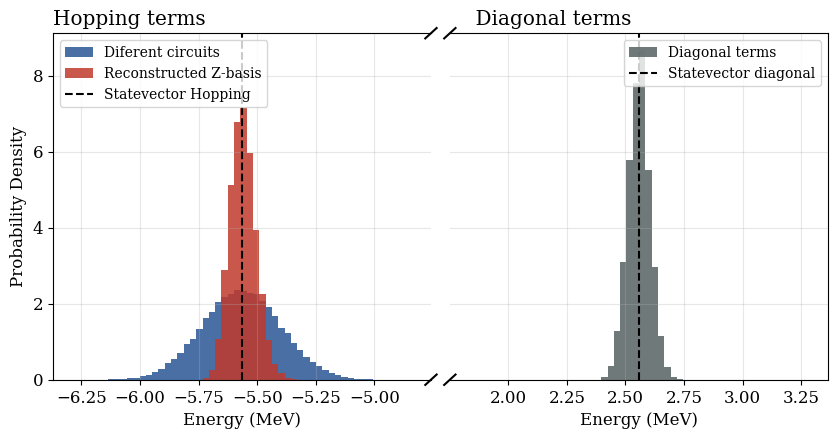

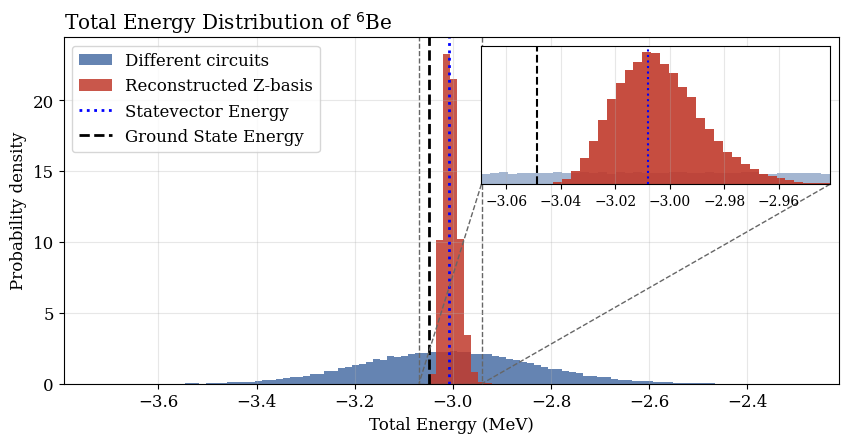

In [9]:
VALOR_CALCULADO = -3.0079065424758444
VALOR_GS_EXACTO = -3.04876320318616
VALOR_DIAG_REF  = 2.556971870608527
VALOR_HOP_REF   = -5.564878413084367
n_experiments = 50000

run_monte_carlo_analysis(composer.Qibo_measure_Energy, n_experiments, VALOR_CALCULADO, VALOR_GS_EXACTO, VALOR_DIAG_REF, VALOR_HOP_REF, save = True)

In [27]:
import numpy as np
from tqdm import tqdm
import contextlib

# Configuración
list_shots = [100,250,500,1000, 2500]


medias_fixed = []
desviaciones_fixed = []

medias_sep_fixed = []
desviaciones_sep_fixed = []



for shots in list_shots:
    composer.nshots = shots
    
    energies = []
    energies_sep = []

    
    print(f'---------------- {shots} Shots ----------------')
    
    # Bucle de repeticiones (Monte Carlo)
    for _ in tqdm(range(1000), leave=False, desc=f"Simulando {shots}"):
        # Silenciamos el output de la función interna si es muy verboso
        with contextlib.redirect_stdout(None): 
            Et_shots, E_diag, E_hop, ansatz = composer.Qibo_measure_Energy()
            
        energies.append(Et_shots)
        energies_sep.append(E_diag+E_hop)
        
    # --- CÁLCULO ESTADÍSTICO ROBUSTO ---
    # Usamos percentiles 16-50-84 para capturar la asimetría
    
    # 1. Energía Total
    print(min(energies))
    p16, med, p84 = np.percentile(energies, [15.87, 50, 84.13])
    medias_fixed.append(np.median(energies))
    desviaciones_fixed.append([med - p16, p84 - med]) # Formato [err_down, err_up]
    
    mean= np.mean(energies_sep)
    std=np.std(energies_sep)
    medias_sep_fixed.append(mean)
    desviaciones_sep_fixed.append(std) # Formato [err_down, err_up]
    
    
    print(f"E_median: {med:.5f}  (-{med-p16:.4f} / +{p84-med:.4f})")
    print(f"E_mean_sep: {mean:.5f}  (+-{std})")


print("\n--- RESULTADOS: MEDIANAS ---")
print("Total:", medias_fixed)

print("\n--- RESULTADOS: ERRORES ASIMÉTRICOS [[down, up], ...] ---")
print("Total Err:", desviaciones_fixed)


---------------- 100 Shots ----------------


-3.0485866996430326
E_median: -2.98225  (-0.0446 / +0.0840)
E_mean_sep: -3.01263  (+-0.5314852328560613)
---------------- 250 Shots ----------------


-3.04864312214564
E_median: -2.99679  (-0.0295 / +0.0381)
E_mean_sep: -3.01632  (+-0.3503358467820183)
---------------- 500 Shots ----------------


-3.044925823476045
E_median: -3.00204  (-0.0195 / +0.0259)
E_mean_sep: -3.00245  (+-0.2421344174676808)
---------------- 1000 Shots ----------------


-3.040211481368539
E_median: -3.00471  (-0.0148 / +0.0165)
E_mean_sep: -3.00436  (+-0.16849611492536035)
---------------- 2500 Shots ----------------


-3.0342773571145596
E_median: -3.00665  (-0.0086 / +0.0098)
E_mean_sep: -3.01104  (+-0.10898452242629199)

--- RESULTADOS: MEDIANAS ---
Total: [np.float64(-2.982253252677865), np.float64(-2.996794233175102), np.float64(-3.002038303226455), np.float64(-3.004710957602491), np.float64(-3.006649937551079)]

--- RESULTADOS: ERRORES ASIMÉTRICOS [[down, up], ...] ---
Total Err: [[np.float64(0.04464561687786395), np.float64(0.08396630728837051)], [np.float64(0.029484612715650726), np.float64(0.03806738704347312)], [np.float64(0.019489208532679214), np.float64(0.025926572390463143)], [np.float64(0.014757374934134315), np.float64(0.01651537417746285)], [np.float64(0.008599202834429498), np.float64(0.009764747775254712)]]


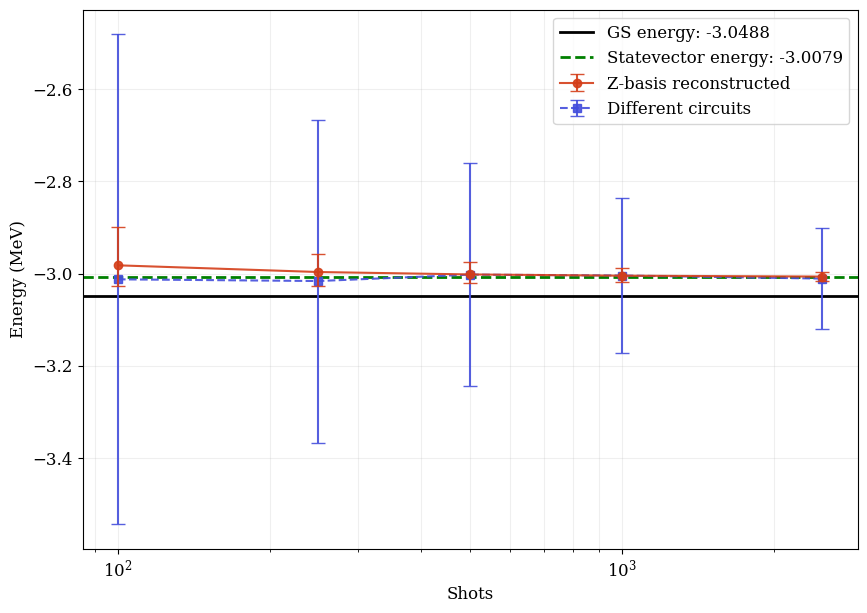

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definimos los límites teóricos
E_FCI = -3.0487979284658944  # Límite físico absoluto (Exacto)

E_Ansatz = -3.0079065424758444 # Límite de tu circuito (VQE Clásico)

# 2. Procesamos los errores para el gráfico
# Convertimos la lista de listas [[err_down, err_up], ...] a array transpuesto (2, N)
y_err_asym = np.array(desviaciones_fixed).T 

plt.figure(figsize=(10, 7))

# --- ZONA PROHIBIDA (FÍSICA) ---
# Sombreamos la zona por debajo del FCI.
# El límite inferior del sombreado será el valor más bajo entre tus datos o un 10% más abajo del FCI
# (Multiplicar por 1.1 un número negativo lo hace "más negativo", es decir, más abajo)
lower_bound_plot = min(np.min(medias_fixed), E_FCI ) 

# 3. Líneas de Referencia
# Línea del Ground State Verdadero (FCI)
plt.axhline(E_FCI, color='black', linestyle='-', linewidth=2, label=f'GS energy: {E_FCI:.4f}')

# Línea de tu Solución Clásica (Ansatz)
plt.axhline(E_Ansatz, color='green', linestyle='--', linewidth=2, label=f'Statevector energy: {E_Ansatz:.4f}')

# 4. Tus datos experimentales
plt.errorbar(list_shots, medias_fixed, yerr=y_err_asym, 
             fmt='-o',               # Línea sólida (-) con marcador círculo (o)
             linewidth=1.5,          # Grosor de línea estándar
             markersize=6,           # Tamaño de marcador legible
             capsize=5,              # Topes de las barras de error
             color='#D43E19',        # Color principal (línea y marcador)
             ecolor='#D43E19',       # Color de la barra de error (mismo o más oscuro)
             alpha=0.9,              # Ligera transparencia para ver solapamientos
             label='Z-basis reconstructed', 
             zorder=10)

# --- SERIE 2: Different Circuits (Estilo: Azul, Discontinuo, Cuadrado) ---
# Usamos el color azul (#434EDC) que usaste para 'Different circuits' antes
plt.errorbar(list_shots, medias_sep_fixed, yerr=desviaciones_sep_fixed, 
             fmt='--s',              # Línea discontinua (--) con marcador cuadrado (s)
             linewidth=1.5,
             markersize=6,
             capsize=5,
             color='#434EDC',        
             ecolor='#434EDC',
             alpha=0.9,
             label='Different circuits', 
             zorder=9)
# Decoración
plt.xscale('log') 
plt.xlabel("Shots", fontsize=12)
plt.ylabel("Energy (MeV)", fontsize=12)
plt.legend(loc='upper right') # O 'lower right' si molesta arriba
plt.grid(True, which="both", ls="-", alpha=0.2)

# Ajuste automático del eje Y para que se vea bien la zona de interés
# Dejamos un pequeño margen arriba del Ansatz y abajo del FCI


plt.show()

In [29]:
list_shots=[1000, 3000, 5000, 10000]

desviaciones_fixed=[]
medias_fixed=[]

desviaciones_fixed_diag=[]
medias_fixed_diag=[]

desviaciones_fixed_hop=[]
medias_fixed_hop=[]

for shots in list_shots:
    composer.nshots = shots
    energies=[]
    e_diags=[]
    e_hops=[]
    print('----------------',shots,'----------------')
    for _ in tqdm(range(1000), leave=False, desc="Repeticiones"):
        with contextlib.redirect_stdout(f):
            Et_shots, E_diag, E_hop, ansatz = composer.Qibo_measure_Energy()
        energies.append(Et_shots)
        e_diags.append(E_diag)
        e_hops.append(E_hop)
        
    desviaciones_fixed.append(np.std(energies))
    medias_fixed.append(np.mean(energies))
    
    desviaciones_fixed_diag.append(np.std(e_diags))
    medias_fixed_diag.append(np.mean(e_diags))
    
    desviaciones_fixed_hop.append(np.std(e_hops))
    medias_fixed_hop.append(np.mean(e_hops))
    
    print('DONE')
    
print(medias_fixed)  
print(desviaciones_fixed)

print(medias_fixed_diag)
print(desviaciones_fixed_diag)

print(medias_fixed_hop)
print(desviaciones_fixed_hop)  

---------------- 1000 ----------------


DONE
---------------- 3000 ----------------


DONE
---------------- 5000 ----------------


DONE
---------------- 10000 ----------------


DONE
[np.float64(-3.0034939131000287), np.float64(-3.006668119405908), np.float64(-3.006896891281493), np.float64(-3.0075994776539803)]
[np.float64(0.016054416108549744), np.float64(0.008958211581456689), np.float64(0.006764159934180937), np.float64(0.004790182201422053)]
[np.float64(2.5553760942), np.float64(2.557639157533333), np.float64(2.55665047484), np.float64(2.55664087062)]
[np.float64(0.04697790798149496), np.float64(0.027088615464161095), np.float64(0.021610703090568287), np.float64(0.014219034707739773)]
[np.float64(-5.5701342454338505), np.float64(-5.5646443791682705), np.float64(-5.563459509364557), np.float64(-5.566580292740598)]
[np.float64(0.1643828805982763), np.float64(0.09724589728837701), np.float64(0.07526191496091418), np.float64(0.053640290060410094)]


In [ ]:
nshots=[1000, 3000, 5000, 10000]
results={}
k=0
fallos = 0
with open("Convergence_data/Be6_QP_ADAPT_2_layer.dat", "w") as file:
    file.write("shots theta1_mean theta1_std theta2_mean theta2_std energy_mean energy_std energy_mean_fixed energy_std_fixed\n")
    
    for shots in nshots:
        
        fixed_E=medias_fixed[k]
        fiexd_std=desviaciones_fixed[k]
        thetas_1=[]
        thetas_2=[]
        energias=[]
        print('--------------', shots, ' shots --------------')
        for _ in tqdm(range(100), leave=False, desc="Repeticiones"):
            with contextlib.redirect_stdout(f):       
                data_mix, nucleo = QP_Quantum_ADAPT_minimization(nuc, ref_state = ref_state, shell='p', max_layers=2, threshold=1e-2, exact=False, nshots=shots)
                if len(data_mix['parameters'])==2:
                    thetas_1.append(data_mix['parameters'][0])
                    thetas_2.append(data_mix['parameters'][1])
                    energias.append(data_mix['Energy'])
                else:
                    fallos += 1
            
        print('DONE')
        results[shots] = {'theta_1': [np.mean(thetas_1), np.std(thetas_1)], 'theta_2':[np.mean(thetas_2), np.std(thetas_2)],  'energy':[np.mean(energias), np.std(energias)]}
        
        media_t1, std_t1 = results[shots]['theta_1']
        media_t2, std_t2 = results[shots]['theta_2']

        media_E, std_E = results[shots]['energy']
        
        
        file.write(f"{shots} {media_t1:.6f} {std_t1:.6f} {media_t2:.6f} {std_t2:.6f} {media_E:.6f} {std_E:.6f} {fixed_E:.6f} {fiexd_std:.6f}\n")
        
        k += 1
        print(fallos)


-------------- 1000  shots --------------


Repeticiones:   0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
nshots=[1000, 3000, 5000, 10000]
results={}
k=0
data_fallo=[]

with open("Convergence_data/Be6_QP_Roto_2_layer.dat", "w") as file:
    file.write("shots theta1_mean theta1_std theta2_mean theta2_std energy_mean energy_std energy_mean_fixed energy_std_fixed\n")
    
    for shots in nshots:
        fallos = 0
        fixed_E=medias_fixed[k]
        fiexd_std=desviaciones_fixed[k]
        thetas_1=[]
        thetas_2=[]
        energias=[]
        print('--------------', shots, ' shots --------------')
        for _ in tqdm(range(100), leave=False, desc="Repeticiones"):
            with contextlib.redirect_stdout(f):       
                data_mix, nucleo = QP_Quantum_Roto_minimization(nuc, ref_state = ref_state, shell='p', max_layers=2, threshold=1e-2, exact=False, nshots=shots)
                if len(data_mix['parameters'])==2:
                    thetas_1.append(data_mix['parameters'][0])
                    thetas_2.append(data_mix['parameters'][1])
                    energias.append(data_mix['Energy'])
                else:
                    data_fallo.append(data_mix)
                    fallos += 1
            
        print('DONE')
        results[shots] = {'theta_1': [np.mean(thetas_1), np.std(thetas_1)], 'theta_2':[np.mean(thetas_2), np.std(thetas_2)],  'energy':[np.mean(energias), np.std(energias)]}
        
        media_t1, std_t1 = results[shots]['theta_1']
        media_t2, std_t2 = results[shots]['theta_2']

        media_E, std_E = results[shots]['energy']
        
        
        file.write(f"{shots} {media_t1:.6f} {std_t1:.6f} {media_t2:.6f} {std_t2:.6f} {media_E:.6f} {std_E:.6f} {fixed_E:.6f} {fiexd_std:.6f}\n")
        
        k += 1
        print(fallos)



-------------- 1000  shots --------------


DONE
0
-------------- 3000  shots --------------


DONE
0
-------------- 5000  shots --------------


DONE
0
-------------- 10000  shots --------------


DONE
0


In [ ]:
nshots=[1000, 3000, 5000, 10000]
results={}
k=0
fallos = 0
with open("Convergence_data/Be6_QP_Roto_ADAPT_2_layer.dat", "w") as file:
    file.write("shots theta1_mean theta1_std theta2_mean theta2_std energy_mean energy_std energy_mean_fixed energy_std_fixed\n")
    
    for shots in nshots:
        
        fixed_E=medias_fixed[k]
        fiexd_std=desviaciones_fixed[k]
        thetas_1=[]
        thetas_2=[]
        energias=[]
        print('--------------', shots, ' shots --------------')
        for _ in tqdm(range(100), leave=False, desc="Repeticiones"):
            with contextlib.redirect_stdout(f):       
                data_mix, nucleo = QP_Quantum_Roto_ADAPT_minimization(nuc, ref_state = ref_state, shell='p', max_layers=2, threshold=1e-2, exact=False, nshots=shots)
                if len(data_mix['parameters'])==2:
                    thetas_1.append(data_mix['parameters'][0])
                    thetas_2.append(data_mix['parameters'][1])
                    energias.append(data_mix['Energy'])
                else:
                    fallos =+ 1
            
        print('DONE')
        results[shots] = {'theta_1': [np.mean(thetas_1), np.std(thetas_1)], 'theta_2':[np.mean(thetas_2), np.std(thetas_2)],  'energy':[np.mean(energias), np.std(energias)]}
        
        media_t1, std_t1 = results[shots]['theta_1']
        media_t2, std_t2 = results[shots]['theta_2']

        media_E, std_E = results[shots]['energy']
        
        
        file.write(f"{shots} {media_t1:.6f} {std_t1:.6f} {media_t2:.6f} {std_t2:.6f} {media_E:.6f} {std_E:.6f} {fixed_E:.6f} {fiexd_std:.6f}\n")
        
        k += 1
        print(fallos)


-------------- 1000  shots --------------


DONE
0
-------------- 3000  shots --------------


DONE
0
-------------- 5000  shots --------------


DONE
0
-------------- 10000  shots --------------


DONE
0


## Convergence test sd shell

In [ ]:
shell='sd'
nuc ='O18'
ref_state = 0

data, nucleus = QP_Roto_minimization(nuc, ref_state = ref_state, shell=shell, max_layers=4, threshold=1e-5)


 --------------------------------------------------------------------------
                            ADAPT for  O18
 --------------------------------------------------------------------------

Initial Energy:  -9.3151
-9.814428280677735 [np.float64(2.5150229187950703)]

------------ LAYER 1 ------------
Operator: 12 13
Energy:  -9.814428280677735
Rel. Error:  0.17745537602937972
Theta: 2.5150229187950703
-10.481416088254 [np.float64(2.5150229187950703), np.float64(0.6067964744369881)]

------------ LAYER 2 ------------
Operator: 12 15
Energy:  -10.481416088254
Rel. Error:  0.12155530526764984
Theta: 0.6067964744369881
-11.169950193828749 [np.float64(2.5150229187950703), np.float64(0.6067964744369881), np.float64(0.7932650140910547)]

------------ LAYER 3 ------------
Operator: 12 14
Energy:  -11.169950193828749
Rel. Error:  0.06384944500109348
Theta: 0.7932650140910547
-11.531373851981947 [np.float64(2.5150229187950703), np.float64(0.6067964744369881), np.float64(0.7932650140910547)

In [ ]:
thetas = data['parameters'].copy()


used_operators = data['used_operators'] 

composer = QP_Circuits_Composser(nucleus='O18',
                              shell='sd',
                              ref_state=0,
                              parameters=thetas,
                              operators_used=used_operators,
                              exact=False,
                              nshots=1000)
 
Et_shots = composer.Qibo_measure_Energy()
print(*Et_shots[:-1])

-11.534695400858725 -8.637085999999998 -3.017438099388055


Simulando 10000 experimentos...


100%|██████████| 10000/10000 [02:28<00:00, 67.20it/s]


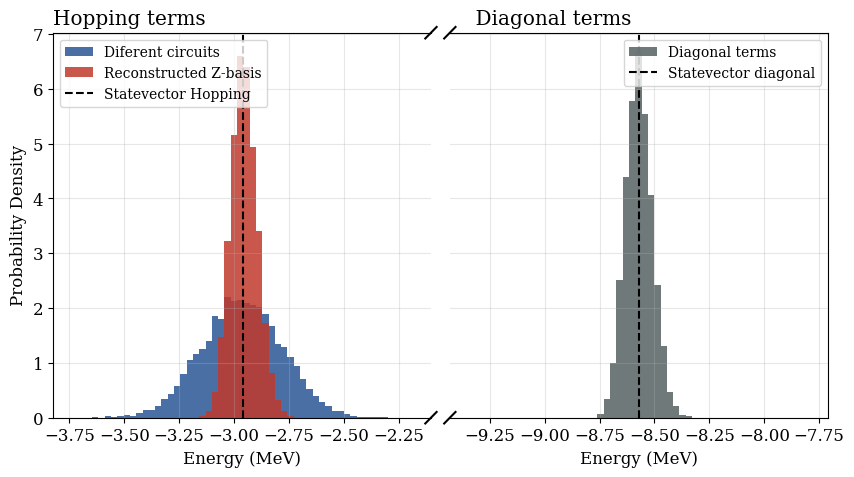

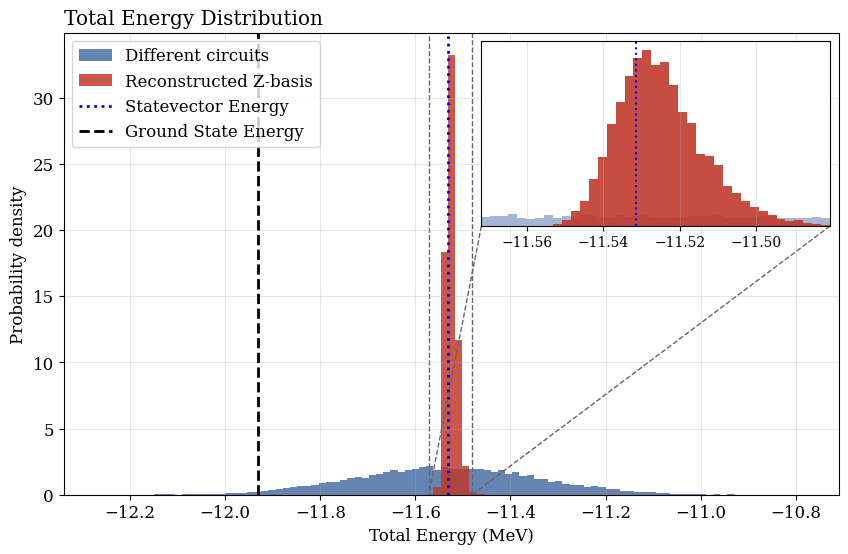

In [ ]:
VALOR_CALCULADO = -11.53137385198194
VALOR_GS_EXACTO = -11.931771136330243
VALOR_DIAG_REF  = -8.570371432032788
VALOR_HOP_REF   = -2.9610024199491494
n_experiments = 10000

run_monte_carlo_analysis(composer.Qibo_measure_Energy, n_experiments, VALOR_CALCULADO, VALOR_GS_EXACTO, VALOR_DIAG_REF, VALOR_HOP_REF)

In [ ]:
shell='sd'
nuc ='O20'
ref_state = 0

data, nucleus = QP_Roto_minimization(nuc, ref_state = ref_state, shell=shell, max_layers=6, threshold=1e-2)

 --------------------------------------------------------------------------
                            ADAPT for  O20
 --------------------------------------------------------------------------

Initial Energy:  -20.00019767937434
-20.707247259680926 [np.float64(2.4378822297515583)]

------------ LAYER 1 ------------
Operator: 13 14
Energy:  -20.707247259680926
Rel. Error:  0.10536946289304927
Theta: 2.4378822297515583
-21.20960771472055 [np.float64(2.4378822297515583), np.float64(0.7756212402374645)]

------------ LAYER 2 ------------
Operator: 12 14
Energy:  -21.20960771472055
Rel. Error:  0.08366561215531886
Theta: 0.7756212402374645
-21.73184799528053 [np.float64(2.4378822297515583), np.float64(0.7756212402374645), np.float64(0.4311569092641575)]

------------ LAYER 3 ------------
Operator: 12 15
Energy:  -21.73184799528053
Rel. Error:  0.06110287859459273
Theta: 0.4311569092641575
-22.1084105961466 [np.float64(2.4378822297515583), np.float64(0.7756212402374645), np.float64(0.4311

In [ ]:
thetas = data['parameters'].copy()

used_operators = data['used_operators'] 

composer = QP_Circuits_Composser(nucleus='O20',
                              shell='sd',
                              ref_state=0,
                              parameters=thetas,
                              operators_used=used_operators,
                              exact=False,
                              nshots=1000)
 
Et_shots = composer.Qibo_measure_Energy()
print(*Et_shots[:-1])


-22.71919533152932 -18.63811033862532 -4.153562787305759


Simulando 10000 experimentos...


100%|██████████| 10000/10000 [16:46<00:00,  9.94it/s]


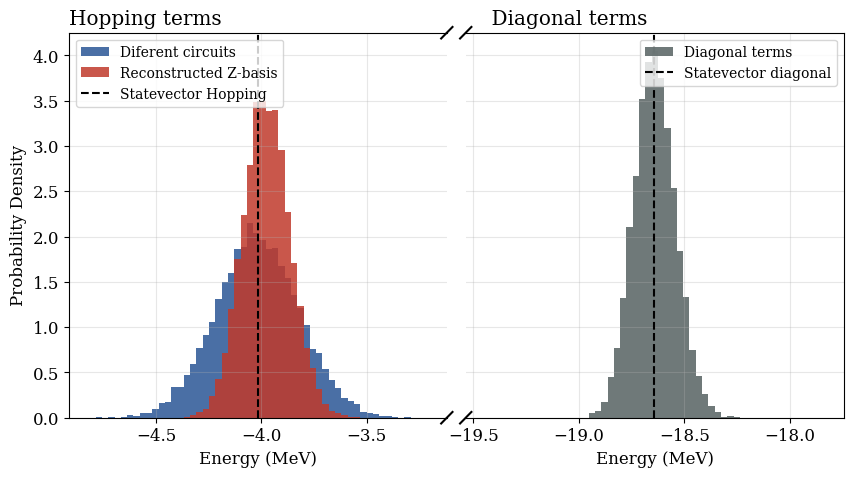

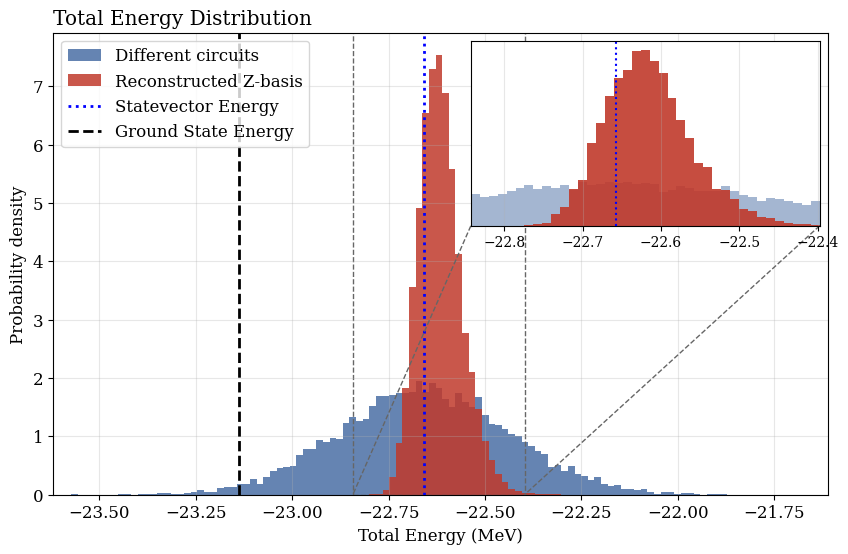

In [ ]:
VALOR_CALCULADO = -22.657579315781554
VALOR_GS_EXACTO = -23.13909950003768
VALOR_DIAG_REF  = -18.641269312389323
VALOR_HOP_REF   = -4.016310003392225
n_experiments = 10000

run_monte_carlo_analysis(composer.Qibo_measure_Energy_complex, n_experiments, VALOR_CALCULADO, VALOR_GS_EXACTO, VALOR_DIAG_REF, VALOR_HOP_REF)

In [ ]:
import numpy as np
from tqdm import tqdm
import contextlib

# Configuración
list_shots = [500, 1000, 2500, 5000, 10000]


medias_fixed = []
desviaciones_fixed = []

medias_sep_fixed = []
desviaciones_sep_fixed = []



for shots in list_shots:
    composer.nshots = shots
    
    energies = []
    energies_sep = []

    
    print(f'---------------- {shots} Shots ----------------')
    
    # Bucle de repeticiones (Monte Carlo)
    for _ in tqdm(range(2000), leave=False, desc=f"Simulando {shots}"):
        # Silenciamos el output de la función interna si es muy verboso
        with contextlib.redirect_stdout(None): 
            Et_shots, E_diag, E_hop, ansatz = composer.Qibo_measure_Energy()
            
        energies.append(Et_shots)
        energies_sep.append(E_diag+E_hop)
        
    # --- CÁLCULO ESTADÍSTICO ROBUSTO ---
    # Usamos percentiles 16-50-84 para capturar la asimetría
    
    # 1. Energía Total
    print(min(energies))
    p16, med, p84 = np.percentile(energies, [15.87, 50, 84.13])
    medias_fixed.append(np.mean(energies))
    desviaciones_fixed.append([med - p16, p84 - med]) # Formato [err_down, err_up]
    
    mean= np.mean(energies_sep)
    std=np.std(energies_sep)
    medias_sep_fixed.append(mean)
    desviaciones_sep_fixed.append(std) # Formato [err_down, err_up]
    
    
    print(f"E_median: {med:.5f}  (-{med-p16:.4f} / +{p84-med:.4f})")
    print(f"E_mean_sep: {mean:.5f}  (+-{std})")


print("\n--- RESULTADOS: MEDIANAS ---")
print("Total:", medias_fixed)

print("\n--- RESULTADOS: ERRORES ASIMÉTRICOS [[down, up], ...] ---")
print("Total Err:", desviaciones_fixed)


---------------- 500 Shots ----------------


-22.759670645988525
E_median: -22.56672  (-0.0693 / +0.0798)
E_mean_sep: -22.66838  (+-0.3143290741324)
---------------- 1000 Shots ----------------


-22.754599113515468
E_median: -22.62002  (-0.0501 / +0.0543)
E_mean_sep: -22.65762  (+-0.22308373466305204)
---------------- 2500 Shots ----------------


-22.754813219566422
E_median: -22.65591  (-0.0353 / +0.0468)
E_mean_sep: -22.66109  (+-0.13915481932259852)
---------------- 5000 Shots ----------------


-22.738278284768768
E_median: -22.66091  (-0.0313 / +0.0362)
E_mean_sep: -22.65568  (+-0.09730367908403319)
---------------- 10000 Shots ----------------


-22.719595853425858
E_median: -22.65657  (-0.0267 / +0.0222)
E_mean_sep: -22.65639  (+-0.06940327272775672)

--- RESULTADOS: MEDIANAS ---
Total: [np.float64(-22.56040332722581), np.float64(-22.617175524257025), np.float64(-22.65145877488313), np.float64(-22.65919258258651), np.float64(-22.65765411513944)]

--- RESULTADOS: ERRORES ASIMÉTRICOS [[down, up], ...] ---
Total Err: [[np.float64(0.06925446629702847), np.float64(0.0798047193601441)], [np.float64(0.0500925163506345), np.float64(0.05430117250656252)], [np.float64(0.03526833159156695), np.float64(0.04676591949667497)], [np.float64(0.03126286029056757), np.float64(0.03616450944202754)], [np.float64(0.026741701747056368), np.float64(0.022214743413339733)]]


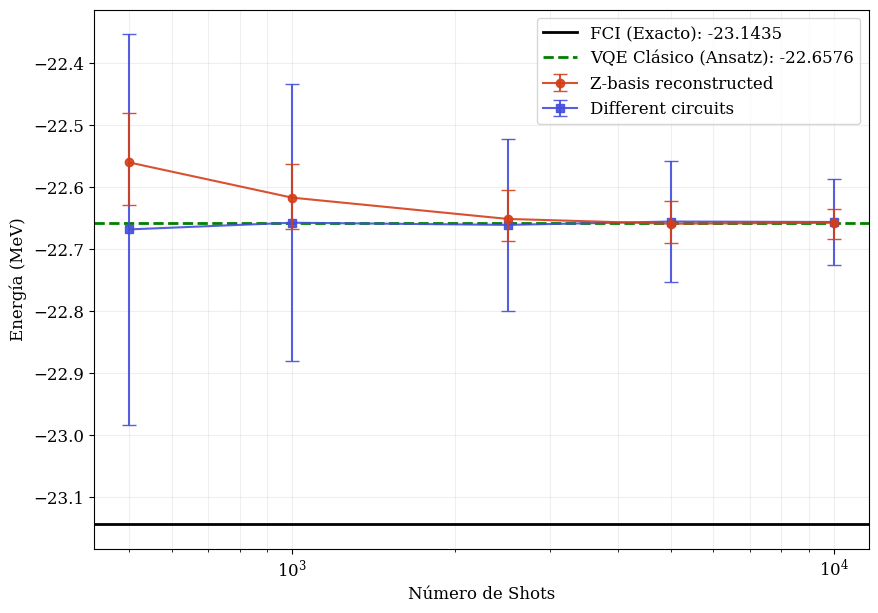

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definimos los límites teóricos
E_FCI = -23.14352598319472  # Límite físico absoluto (Exacto)

E_Ansatz = -22.657579315781554 # Límite de tu circuito (VQE Clásico)

# 2. Procesamos los errores para el gráfico
# Convertimos la lista de listas [[err_down, err_up], ...] a array transpuesto (2, N)
y_err_asym = np.array(desviaciones_fixed).T 

plt.figure(figsize=(10, 7))

# --- ZONA PROHIBIDA (FÍSICA) ---
# Sombreamos la zona por debajo del FCI.
# El límite inferior del sombreado será el valor más bajo entre tus datos o un 10% más abajo del FCI
# (Multiplicar por 1.1 un número negativo lo hace "más negativo", es decir, más abajo)
lower_bound_plot = min(np.min(medias_fixed), E_FCI ) 

# 3. Líneas de Referencia
# Línea del Ground State Verdadero (FCI)
plt.axhline(E_FCI, color='black', linestyle='-', linewidth=2, label=f'FCI (Exacto): {E_FCI:.4f}')

# Línea de tu Solución Clásica (Ansatz)
plt.axhline(E_Ansatz, color='green', linestyle='--', linewidth=2, label=f'VQE Clásico (Ansatz): {E_Ansatz:.4f}')

# 4. Tus datos experimentales
plt.errorbar(list_shots, medias_fixed, yerr=y_err_asym, 
             fmt='-o',               # Línea sólida (-) con marcador círculo (o)
             linewidth=1.5,          # Grosor de línea estándar
             markersize=6,           # Tamaño de marcador legible
             capsize=5,              # Topes de las barras de error
             color='#D43E19',        # Color principal (línea y marcador)
             ecolor='#D43E19',       # Color de la barra de error (mismo o más oscuro)
             alpha=0.9,              # Ligera transparencia para ver solapamientos
             label='Z-basis reconstructed', 
             zorder=10)

# --- SERIE 2: Different Circuits (Estilo: Azul, Discontinuo, Cuadrado) ---
# Usamos el color azul (#434EDC) que usaste para 'Different circuits' antes
plt.errorbar(list_shots, medias_sep_fixed, yerr=desviaciones_sep_fixed, 
             fmt='-s',              # Línea discontinua (--) con marcador cuadrado (s)
             linewidth=1.5,
             markersize=6,
             capsize=5,
             color='#434EDC',        
             ecolor='#434EDC',
             alpha=0.9,
             label='Different circuits', 
             zorder=9)
# Decoración
plt.xscale('log') 
plt.xlabel("Número de Shots", fontsize=12)
plt.ylabel("Energía (MeV)", fontsize=12)
plt.legend(loc='upper right') # O 'lower right' si molesta arriba
plt.grid(True, which="both", ls="-", alpha=0.2)

# Ajuste automático del eje Y para que se vea bien la zona de interés
# Dejamos un pequeño margen arriba del Ansatz y abajo del FCI


plt.show()

In [ ]:
shell='sd'
nuc ='O22'
ref_state = 0

data, nucleus = QP_Roto_minimization(nuc, ref_state = ref_state, shell=shell, max_layers=10, threshold=1e-7)

 --------------------------------------------------------------------------
                            ADAPT for  O22
 --------------------------------------------------------------------------

Initial Energy:  -32.428921584538365
-32.650305383097006 [np.float64(0.12113699106955561)]

------------ LAYER 1 ------------
Operator: 12 16
Energy:  -32.650305383097006
Rel. Error:  0.0377409428859263
Theta: 0.12113699106955561
-32.84360103755791 [np.float64(0.12113699106955561), np.float64(-0.11365464615752247)]

------------ LAYER 2 ------------
Operator: 14 17
Energy:  -32.84360103755791
Rel. Error:  0.03204419695894672
Theta: -0.11365464615752247
-33.02111248405334 [np.float64(0.12113699106955561), np.float64(-0.11365464615752247), np.float64(0.19147147381753582)]

------------ LAYER 3 ------------
Operator: 12 15
Energy:  -33.02111248405334
Rel. Error:  0.026812638015547775
Theta: 0.19147147381753582
-33.24167065613523 [np.float64(0.12113699106955561), np.float64(-0.11365464615752247), 

In [ ]:
shell='sd'
nuc ='O22'
ref_state = 0

data, nucleus = QP_Quantum_Roto_minimization(nuc, ref_state = ref_state, shell=shell, max_layers=10, threshold=1e-7, exact=False)

 --------------------------------------------------------------------------
                            ADAPT for  O22
 --------------------------------------------------------------------------

Initial Energy:  -32.42892158453836
-32.62171355164288 [np.float64(-0.12284895170202192)]


KeyboardInterrupt: 

In [ ]:
thetas = data['parameters'].copy()

used_operators = data['used_operators'] 

composer = QP_Circuits_Composser(nucleus='O22',
                              shell='sd',
                              ref_state=0,
                              parameters=thetas,
                              operators_used=used_operators,
                              exact=False,
                              nshots=1000)
 
Et_shots = composer.Qibo_measure_Energy()
print(*Et_shots[:-1])


-33.80624110677247 -31.17376629550742 -2.7539711049152067


Simulando 10000 experimentos...


100%|██████████| 10000/10000 [16:12<00:00, 10.28it/s]


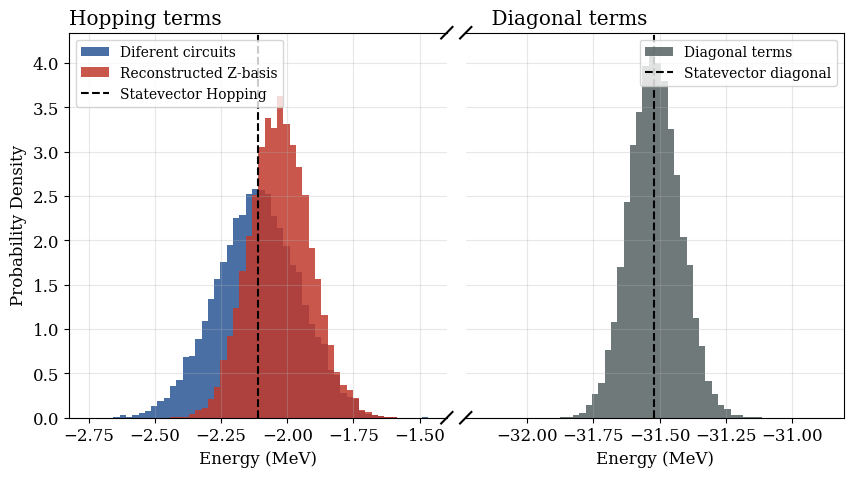

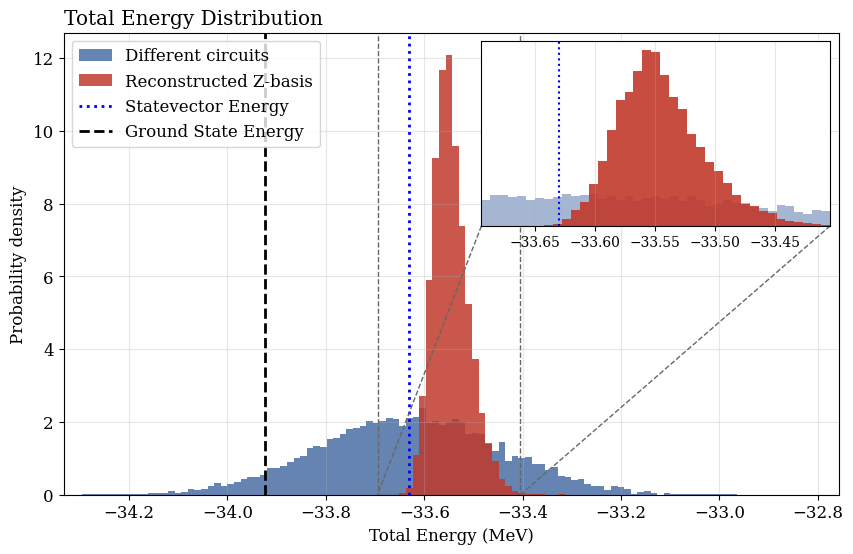

In [ ]:
VALOR_CALCULADO = -33.63026377537971 
VALOR_GS_EXACTO = -33.92383139429753
VALOR_DIAG_REF  = -31.519579136442612
VALOR_HOP_REF   = -2.110684638937092
n_experiments = 10000

run_monte_carlo_analysis(composer.Qibo_measure_Energy_complex, n_experiments, VALOR_CALCULADO, VALOR_GS_EXACTO, VALOR_DIAG_REF, VALOR_HOP_REF)

Simulando 10000 experimentos...


100%|██████████| 10000/10000 [40:21<00:00,  4.13it/s] 


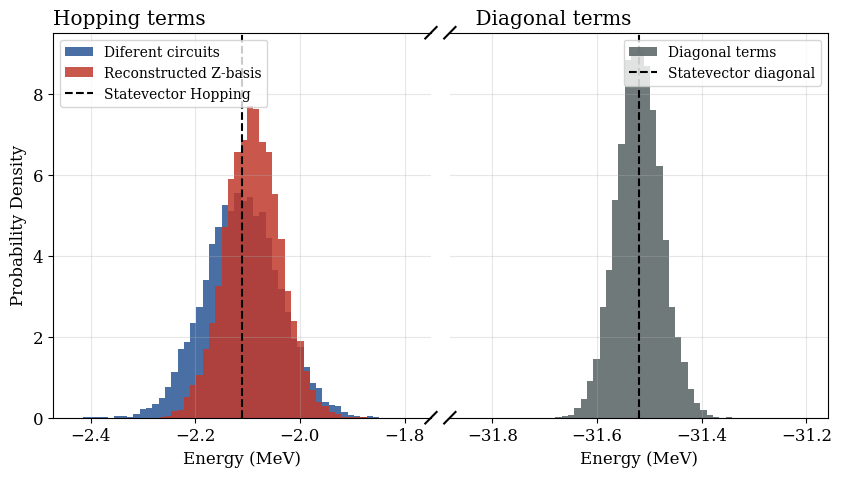

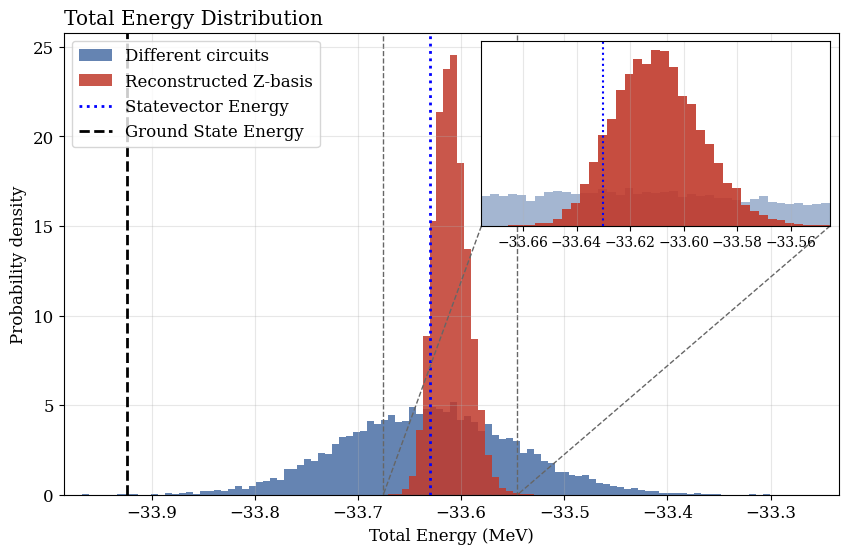

In [ ]:
VALOR_CALCULADO = -33.63026377537971 
VALOR_GS_EXACTO = -33.92383139429753
VALOR_DIAG_REF  = -31.519579136442612
VALOR_HOP_REF   = -2.110684638937092
n_experiments = 10000
composer.nshots = 10000
run_monte_carlo_analysis(composer.Qibo_measure_Energy_complex, n_experiments, VALOR_CALCULADO, VALOR_GS_EXACTO, VALOR_DIAG_REF, VALOR_HOP_REF)

In [ ]:
import numpy as np
from tqdm import tqdm
import contextlib

# Configuración
list_shots = [500, 1000, 2500, 5000, 10000]


medias_fixed = []
desviaciones_fixed = []

medias_sep_fixed = []
desviaciones_sep_fixed = []



for shots in list_shots:
    composer.nshots = shots
    
    energies = []
    energies_sep = []

    
    print(f'---------------- {shots} Shots ----------------')
    
    # Bucle de repeticiones (Monte Carlo)
    for _ in tqdm(range(500), leave=False, desc=f"Simulando {shots}"):
        # Silenciamos el output de la función interna si es muy verboso
        with contextlib.redirect_stdout(None): 
            Et_shots, E_diag, E_hop, ansatz = composer.Qibo_measure_Energy()
            
        energies.append(Et_shots)
        energies_sep.append(E_diag+E_hop)
        
    # --- CÁLCULO ESTADÍSTICO ROBUSTO ---
    # Usamos percentiles 16-50-84 para capturar la asimetría
    
    # 1. Energía Total
    print(min(energies))
    p16, med, p84 = np.percentile(energies, [15.87, 50, 84.13])
    medias_fixed.append(np.mean(energies))
    desviaciones_fixed.append([med - p16, p84 - med]) # Formato [err_down, err_up]
    
    mean= np.mean(energies_sep)
    std=np.std(energies_sep)
    medias_sep_fixed.append(mean)
    desviaciones_sep_fixed.append(std) # Formato [err_down, err_up]
    
    
    print(f"E_median: {med:.5f}  (-{med-p16:.4f} / +{p84-med:.4f})")
    print(f"E_mean_sep: {mean:.5f}  (+-{std})")


print("\n--- RESULTADOS: MEDIANAS ---")
print("Total:", medias_fixed)

print("\n--- RESULTADOS: ERRORES ASIMÉTRICOS [[down, up], ...] ---")
print("Total Err:", desviaciones_fixed)


---------------- 500 Shots ----------------


-33.79413563422268
E_median: -33.65166  (-0.0695 / +0.0800)
E_mean_sep: -33.86454  (+-0.2920884026127096)
---------------- 1000 Shots ----------------


-33.848783868954506
E_median: -33.74654  (-0.0398 / +0.0450)
E_mean_sep: -33.87159  (+-0.20439947747917403)
---------------- 2500 Shots ----------------


-33.885377377577576
E_median: -33.81819  (-0.0253 / +0.0261)
E_mean_sep: -33.87065  (+-0.13247364380029608)
---------------- 5000 Shots ----------------


-33.88518838099989
E_median: -33.84539  (-0.0156 / +0.0178)
E_mean_sep: -33.87773  (+-0.09497546098892025)
---------------- 10000 Shots ----------------


-33.89573734617148
E_median: -33.86283  (-0.0088 / +0.0122)
E_mean_sep: -33.87842  (+-0.06518458308861895)

--- RESULTADOS: MEDIANAS ---
Total: [np.float64(-33.64459922698139), np.float64(-33.742623163886094), np.float64(-33.817519917153696), np.float64(-33.8447525903964), np.float64(-33.861025201564054)]

--- RESULTADOS: ERRORES ASIMÉTRICOS [[down, up], ...] ---
Total Err: [[np.float64(0.0694741294864798), np.float64(0.07996846224553167)], [np.float64(0.039778972478792696), np.float64(0.04501997813994052)], [np.float64(0.02526845400205957), np.float64(0.026140523977630892)], [np.float64(0.015558662799485035), np.float64(0.017805762902199262)], [np.float64(0.00878811649671718), np.float64(0.012215928579941249)]]


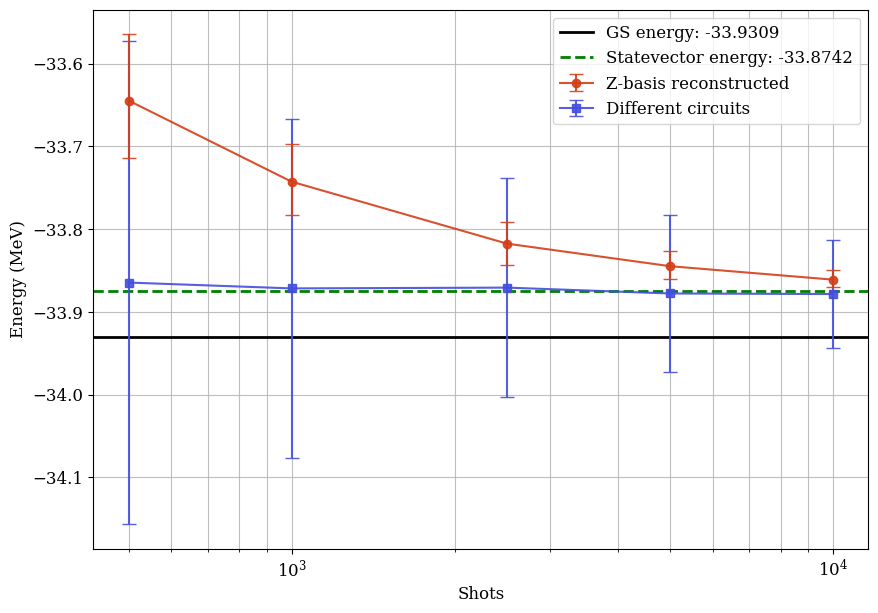

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definimos los límites teóricos

E_FCI = -33.93088913189246  # Límite físico absoluto (Exacto)

E_Ansatz = -33.87420215930574 # Límite de tu circuito (VQE Clásico)

# 2. Procesamos los errores para el gráfico
# Convertimos la lista de listas [[err_down, err_up], ...] a array transpuesto (2, N)
y_err_asym = np.array(desviaciones_fixed).T 

plt.figure(figsize=(10, 7))

# --- ZONA PROHIBIDA (FÍSICA) ---
# Sombreamos la zona por debajo del FCI.
# El límite inferior del sombreado será el valor más bajo entre tus datos o un 10% más abajo del FCI
# (Multiplicar por 1.1 un número negativo lo hace "más negativo", es decir, más abajo)
lower_bound_plot = min(np.min(medias_fixed), E_FCI ) 

# 3. Líneas de Referencia
# Línea del Ground State Verdadero (FCI)
plt.axhline(E_FCI, color='black', linestyle='-', linewidth=2, label=f'GS energy: {E_FCI:.4f}')

# Línea de tu Solución Clásica (Ansatz)
plt.axhline(E_Ansatz, color='green', linestyle='--', linewidth=2, label=f'Statevector energy: {E_Ansatz:.4f}')

# 4. Tus datos experimentales
plt.errorbar(list_shots, medias_fixed, yerr=y_err_asym, 
             fmt='-o',               # Línea sólida (-) con marcador círculo (o)
             linewidth=1.5,          # Grosor de línea estándar
             markersize=6,           # Tamaño de marcador legible
             capsize=5,              # Topes de las barras de error
             color='#D43E19',        # Color principal (línea y marcador)
             ecolor='#D43E19',       # Color de la barra de error (mismo o más oscuro)
             alpha=0.9,              # Ligera transparencia para ver solapamientos
             label='Z-basis reconstructed', 
             zorder=10)

# --- SERIE 2: Different Circuits (Estilo: Azul, Discontinuo, Cuadrado) ---
# Usamos el color azul (#434EDC) que usaste para 'Different circuits' antes
plt.errorbar(list_shots, medias_sep_fixed, yerr=desviaciones_sep_fixed, 
             fmt='-s',              # Línea discontinua (--) con marcador cuadrado (s)
             linewidth=1.5,
             markersize=6,
             capsize=5,
             color='#434EDC',        
             ecolor='#434EDC',
             alpha=0.9,
             label='Different circuits', 
             zorder=9)
# Decoración
plt.xscale('log') 
plt.xlabel("Shots", fontsize=12)
plt.ylabel("Energy (MeV)", fontsize=12)
plt.legend(loc='upper right') # O 'lower right' si molesta arriba
plt.grid(True, which="both", ls="-", alpha=0.8)

# Ajuste automático del eje Y para que se vea bien la zona de interés
# Dejamos un pequeño margen arriba del Ansatz y abajo del FCI


plt.show()

## Deviation analysis

In [ ]:
shell='sd'
nuc ='O22'
ref_state = 0

data, nucleus = QP_Roto_minimization(nuc, ref_state = ref_state, shell=shell, max_layers=1, threshold=1e-7)

 --------------------------------------------------------------------------
                            ADAPT for  O22
 --------------------------------------------------------------------------

Initial Energy:  -32.428921584538365
-32.650305383097006 [np.float64(0.12113699106955561)]

------------ LAYER 1 ------------
Operator: 12 16
Energy:  -32.650305383097006
Rel. Error:  0.0377409428859263
Theta: 0.12113699106955561

Operators used for each layer:
Layer 0: Operator 12,16, Theta = 0.12113699106955561

 Final energy result: -32.650305383097006	 Final relative error is 0.0377409428859263
[np.float64(-32.428921584538365), np.float64(-32.650305383097006)]
Number of energy measurements: 62


In [ ]:
thetas = data['parameters'].copy()

used_operators = data['used_operators'] 
thetas[0]=0.04
composer = QP_Circuits_Composser(nucleus='O22',
                              shell='sd',
                              ref_state=0,
                              parameters=thetas,
                              operators_used=used_operators,
                              exact=False,
                              nshots=500)
 
Et_shots = composer.Qibo_measure_Energy()
print(*Et_shots[:-1])


-32.59962641223448 -32.370050083824395 -0.22591350954385972


Simulando 1000 experimentos...


100%|██████████| 1000/1000 [01:22<00:00, 12.19it/s]


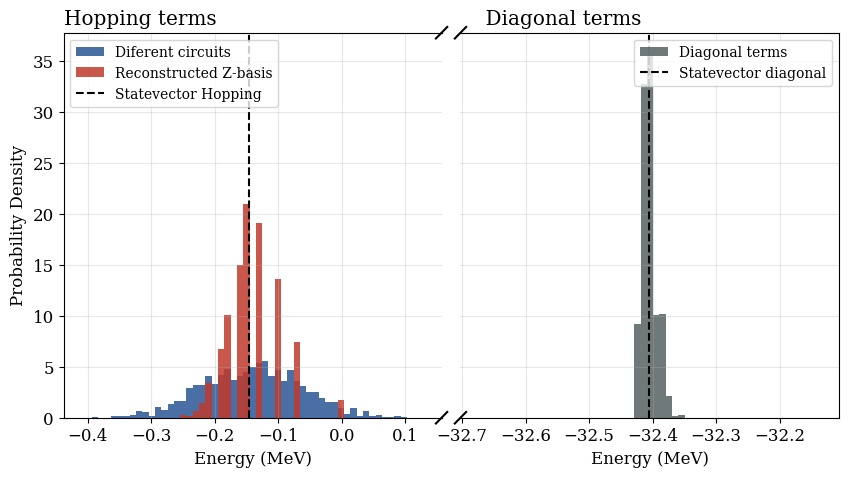

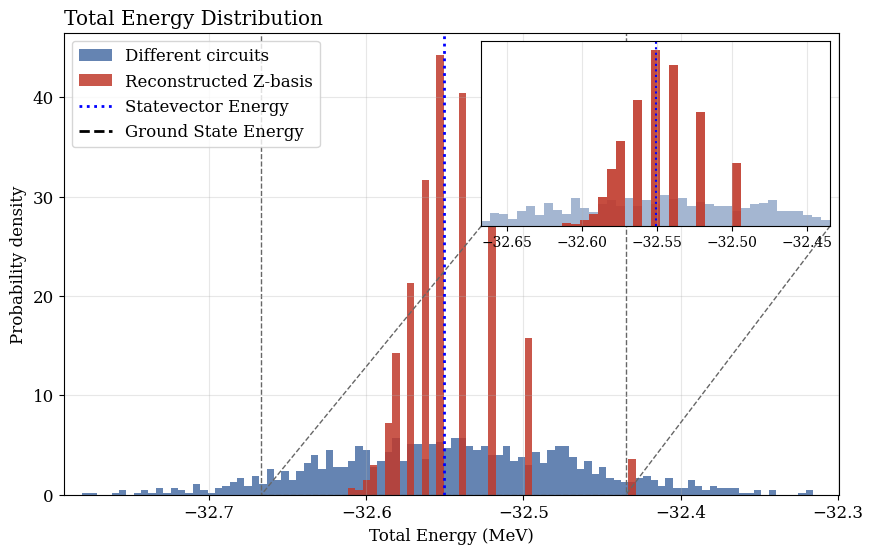

In [ ]:
VALOR_CALCULADO = -32.55071848984703
VALOR_GS_EXACTO = -33.92383139429753
VALOR_DIAG_REF  = -32.40538554082726
VALOR_HOP_REF   = -0.14533294901976843
n_experiments = 1000
composer.nshots = 2500
run_monte_carlo_analysis(composer.Qibo_measure_Energy_complex, n_experiments, VALOR_CALCULADO, VALOR_GS_EXACTO, VALOR_DIAG_REF, VALOR_HOP_REF)

In [ ]:
data, nucleus = QP_Quantum_Roto_minimization('He8', shell='p', max_layers=3)

 --------------------------------------------------------------------------
                            ADAPT for  He8
 --------------------------------------------------------------------------

Initial Energy:  0.5398000000000001
-1.6322226130325215 [np.float64(0.5233910757361742)]

------------ LAYER 1 ------------
Operator: 6 8
Energy:  -1.6322226130325215
Rel. Error:  0.5171563086626669
Theta: 0.5233910757361742
-3.2987319508239326 [np.float64(0.5233910757361742), np.float64(-0.4715029779821534)]

------------ LAYER 2 ------------
Operator: 7 8
Energy:  -3.2987319508239326
Rel. Error:  0.024169926852683557
Theta: -0.4715029779821534
-3.3724345193887317 [np.float64(0.5233910757361742), np.float64(-0.4715029779821534), np.float64(-0.0919823772815682)]

------------ LAYER 3 ------------
Operator: 6 8
Energy:  -3.3724345193887317
Rel. Error:  0.0023672511743007925
Theta: -0.0919823772815682

Operators used for each layer:
Layer 0: Operator 6,8, Theta = 0.5233910757361742
Layer 1: Oper

In [ ]:
res = QP_Circuits_Composser('He6', parameters = data['parameters'], operators_used=data['used_operators'])

print(res.Qibo_measure_Energy())

(0.54649+0j)|001> + (0.83747+0j)|100>
(np.float64(-0.888211310174134), np.float64(2.556971870608527), np.float64(-3.4451831807826587), <qibo.result.QuantumState object at 0x000001CF26363310>)


In [ ]:
import numpy as np
from tqdm import tqdm

def analyze_bias_and_entropy(range_thetas, composer_shots, composer_exact, shots, trials):
    """
    Realiza un barrido de parámetros para medir sesgo de energía y entropía.
    
    Args:
        ansatz_builder: Función que devuelve el circuito configurado para un theta.
        hamiltonian: Operador Hamiltoniano del sistema (ej. Oxígeno-22).
        theta_range: Array con los valores del parámetro entre -pi y pi.
        shots: Número de medidas por ejecución.
        trials: Número de repeticiones para promediar la estadística.
    """
    results = {
        "entropy_sv": [],
        "energy_sv": [],
        "energy_mean": [],
        "energy_median":[],
        "bias": [],
        "err": [],
        "energy_mean_dif": [],
        "energy_median_dif":[],
        "bias_dif": [],
        "err_dif": []
    }
    
    composer_shots.nshots=shots

    for theta in tqdm(range_thetas):
        with contextlib.redirect_stdout(f):   
            composer_shots.parameters[-1]=theta
            composer_exact.parameters[-1]=theta
            
            e_sv, e_diag_sv, e_hop_sv, ansatz_sv = composer_exact.Qibo_measure_Energy_complex()
            probs = ansatz_sv.probabilities()
            entropy_sv = -np.sum(probs * np.log(probs + 1e-15))
                
            measured_energies = []
            measured_energies_dif_circs = []
            for _ in range(trials):
                # Llamada al método complejo de medida
                # Desempaquetamos los componentes E_t, E_diag, E_hop_simple y el ansatz
                e_t, e_diag, e_hop, ansatz = composer_shots.Qibo_measure_Energy_complex()
                measured_energies.append(e_t)
                measured_energies_dif_circs.append(e_hop+e_diag)
                
                
            # Procesamiento estadístico del sesgo y la dispersión
            mean_measured = np.mean(measured_energies)
            median_measured = np.median(measured_energies)
            bias = median_measured - e_sv
            p16, p84 = np.percentile(measured_energies, [16, 84])
            
            results["entropy_sv"].append(entropy_sv)
            results["energy_sv"].append(e_sv)
            results["energy_mean"].append(mean_measured)
            results["energy_median"].append(median_measured)
            results["bias"].append(bias)
            results["err"].append((p16,p84))
            
            mean_measured = np.mean(measured_energies_dif_circs)
            median_measured = np.median(measured_energies_dif_circs)
            bias = median_measured - e_sv
            p16, p84 = np.percentile(measured_energies_dif_circs, [16, 84])
            
            results["energy_mean_dif"].append(mean_measured)
            results["energy_median_dif"].append(median_measured)
            results["bias_dif"].append(bias)
            results["err_dif"].append((p16,p84))
        
    return results


thetas = data['parameters'].copy()

used_operators = data['used_operators'] 

composer_exact = QP_Circuits_Composser(nucleus='O22',shell='sd',ref_state=0,parameters=thetas,operators_used=used_operators,exact=True)
 

composer_shots = QP_Circuits_Composser(nucleus='O22',shell='sd',ref_state=0,parameters=thetas,operators_used=used_operators,exact=False, nshots=1000)
 
res = analyze_bias_and_entropy(np.linspace(0,np.pi/4, 100), composer_shots, composer_exact, shots=1000, trials=100)



100%|██████████| 100/100 [13:43<00:00,  8.24s/it]


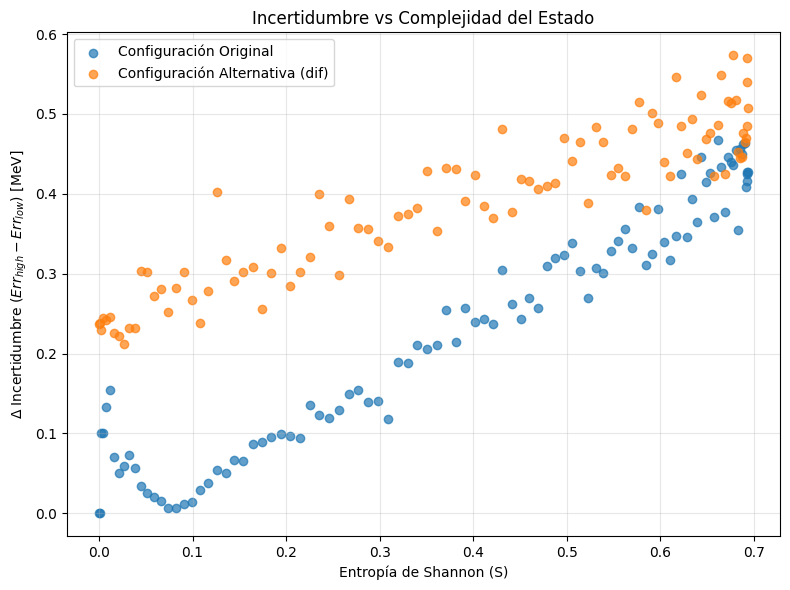

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_error_vs_entropy(results):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Extraemos las bandas de error y medianas para ambas configuraciones
    err_bounds = np.array(results["err"]) 
    medians = np.array(results["energy_median"])

    err_bounds_dif = np.array(results["err_dif"]) 
    medians_dif = np.array(results["energy_median_dif"])
    
    # Calculamos las distancias relativas a la media
    err_low = medians - err_bounds[:, 0]
    err_high = err_bounds[:, 1] - medians

    err_low_dif = medians_dif - err_bounds_dif[:, 0]
    err_high_dif = err_bounds_dif[:, 1] - medians_dif
    
    # Calculamos la métrica de incertidumbre combinada
    diff_err = err_high + err_low
    diff_err_dif = err_high_dif + err_low_dif
    
    # Representamos los datos sin mapa de color, usando etiquetas para diferenciarlos
    ax.scatter(results["entropy_sv"], diff_err, alpha=0.7, label='Configuración Original')
    ax.scatter(results["entropy_sv"], diff_err_dif, alpha=0.7, label='Configuración Alternativa (dif)')
    
    ax.set_xlabel('Entropía de Shannon (S)')
    ax.set_ylabel(r'$\Delta$ Incertidumbre ($Err_{high} - Err_{low}$) [MeV]')
    ax.set_title('Incertidumbre vs Complejidad del Estado')
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

# Ejemplo de uso con tu diccionario de resultados
plot_error_vs_entropy(res)

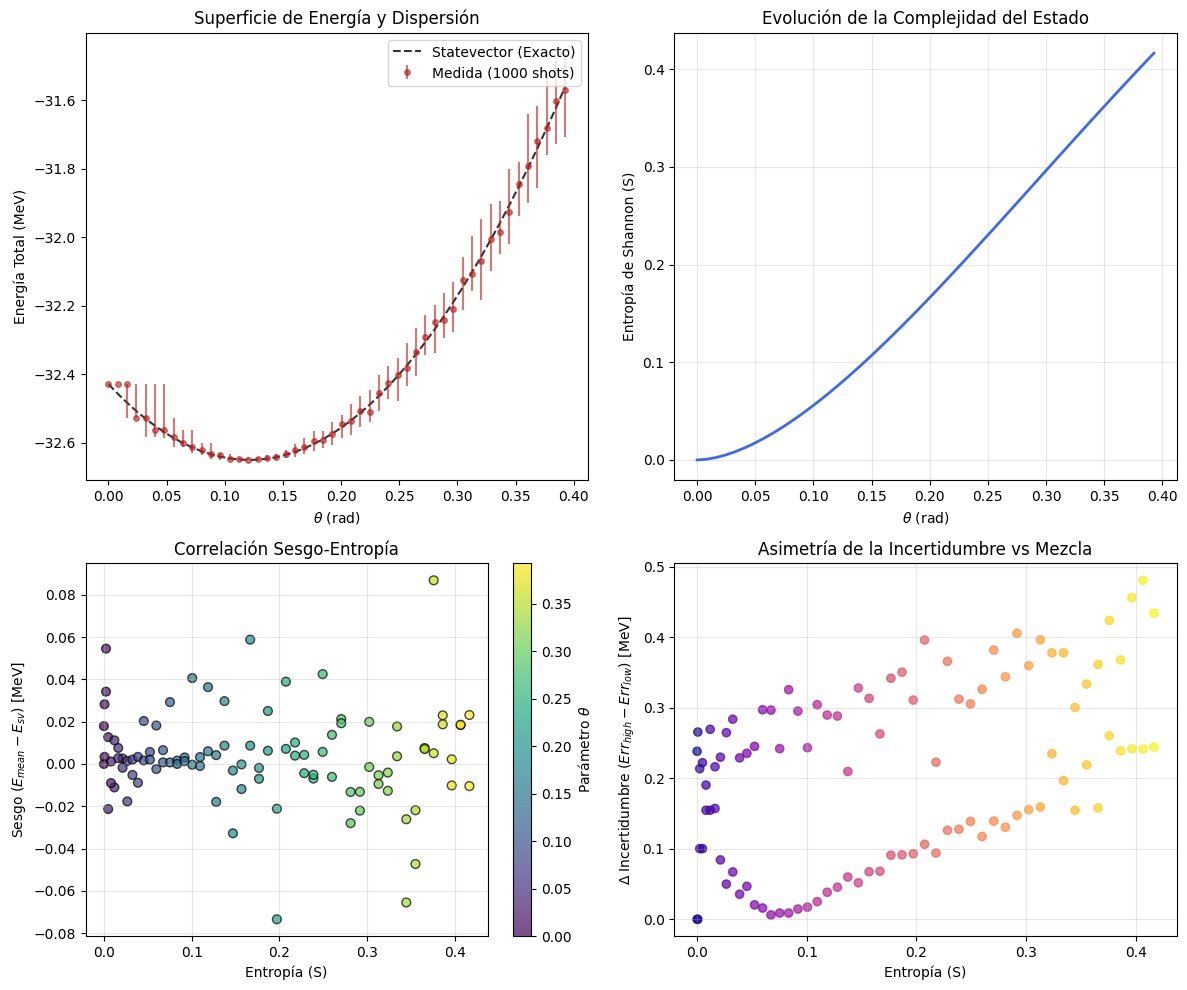

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_nuclear_analysis(theta_range, results, shots):
    # Configuracion de la figura en cuatro cuadrantes 
    err_bounds = np.array(results["err"])
    fig, axs = plt.subplots(2, 2, figsize=(12, 10), gridspec_kw={'height_ratios': [1.2, 1]})
    yerr_asym = [np.array(results["energy_median"]) - err_bounds[:, 0], err_bounds[:, 1] - np.array(results["energy_median"])]
  
    # Cuadrante 1: Superficie de Energia y Precision
    axs[0, 0].plot(theta_range, results["energy_sv"], 'k--', label='Statevector (Exacto)', alpha=0.8)
    axs[0, 0].errorbar(theta_range, results["energy_median"], yerr=yerr_asym, fmt='o', 
                     color='firebrick', markersize=4, label=f'Medida ({shots} shots)', alpha=0.6)
    axs[0, 0].set_ylabel('Energía Total (MeV)')
    axs[0, 0].set_xlabel(r'$\theta$ (rad)')
    axs[0, 0].set_title('Superficie de Energía y Dispersión')
    axs[0, 0].legend()
    axs[0, 1].grid(False) # Limpiamos para consistencia

    # Cuadrante 2: Perfil de Entropia del Estado
    # Nota: Usamos la clave entropy_sv segun tu ultima implementacion
    axs[0, 1].plot(theta_range, results["entropy_sv"], color='royalblue', lw=2)
    axs[0, 1].set_ylabel('Entropía de Shannon (S)')
    axs[0, 1].set_xlabel(r'$\theta$ (rad)')
    axs[0, 1].set_title('Evolución de la Complejidad del Estado')
    axs[0, 1].grid(True, alpha=0.3)

    # Cuadrante 3: Correlacion Directa Sesgo-Entropia
    sc = axs[1, 0].scatter(results["entropy_sv"], results["bias"], c=theta_range, 
                          cmap='viridis', s=40, edgecolors='k', alpha=0.7)
    sc_dif = axs[1, 0].scatter(results["entropy_sv"], results["bias_dif"], c=theta_range, 
                          cmap='viridis', s=40, edgecolors='k', alpha=0.7)
    axs[1, 0].set_xlabel('Entropía (S)')
    axs[1, 0].set_ylabel(r'Sesgo ($E_{mean} - E_{sv}$) [MeV]')
    axs[1, 0].set_title('Correlación Sesgo-Entropía')
    plt.colorbar(sc, ax=axs[1, 0], label=r'Parámetro $\theta$')
    #plt.colorbar(sc_dif, ax=axs[1, 0], label=r'Parámetro $\theta$')
    axs[1, 0].grid(True, alpha=0.3)

    # Cuadrante 4: Escalado de la Incertidumbre con la Mezcla
    # Convertimos la lista de tuplas (p16, p84) a un array de numpy para operar
    err_bounds = np.array(results["err"]) 
    medians = np.array(results["energy_median"])

    err_bounds_dif = np.array(results["err_dif"]) 
    medians_dif = np.array(results["energy_median_dif"])
    
    # Calculamos las distancias relativas a la media
    err_low = medians - err_bounds[:, 0]
    err_high = err_bounds[:, 1] - medians

    err_low_dif = medians_dif - err_bounds_dif[:, 0]
    err_high_dif = err_bounds_dif[:, 1] - medians_dif
    
    # La métrica de asimetría: diferencia entre el brazo superior e inferior
    diff_err = err_high + err_low
    diff_err_dif = err_high_dif + err_low_dif
    
    # Actualización del cuarto panel
    axs[1, 1].scatter(results["entropy_sv"], diff_err, c=theta_range, cmap='plasma', alpha=0.7)
    axs[1, 1].scatter(results["entropy_sv"], diff_err_dif, c=theta_range, cmap='plasma', alpha=0.7)
    axs[1, 1].set_xlabel('Entropía (S)')
    axs[1, 1].set_ylabel(r'$\Delta$ Incertidumbre ($Err_{high} - Err_{low}$) [MeV]')
    axs[1, 1].set_title('Asimetría de la Incertidumbre vs Mezcla')
    axs[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
plot_nuclear_analysis(np.linspace(0, np.pi/8, 50), res, 1000)
    

In [ ]:
thetas = data['parameters'].copy()

used_operators = data['used_operators'] 

composer_exact = QP_Circuits_Composser(nucleus='O22',shell='sd',ref_state=0,parameters=thetas,operators_used=used_operators,exact=True)
 

composer_shots = QP_Circuits_Composser(nucleus='O22',shell='sd',ref_state=0,parameters=thetas,operators_used=used_operators,exact=False, nshots=1000)
 
res = analyze_bias_and_entropy(np.linspace(0, np.pi/4, 50), composer_shots, composer_exact, shots=2500, trials=5000)

100%|██████████| 50/50 [58:50<00:00, 70.61s/it]


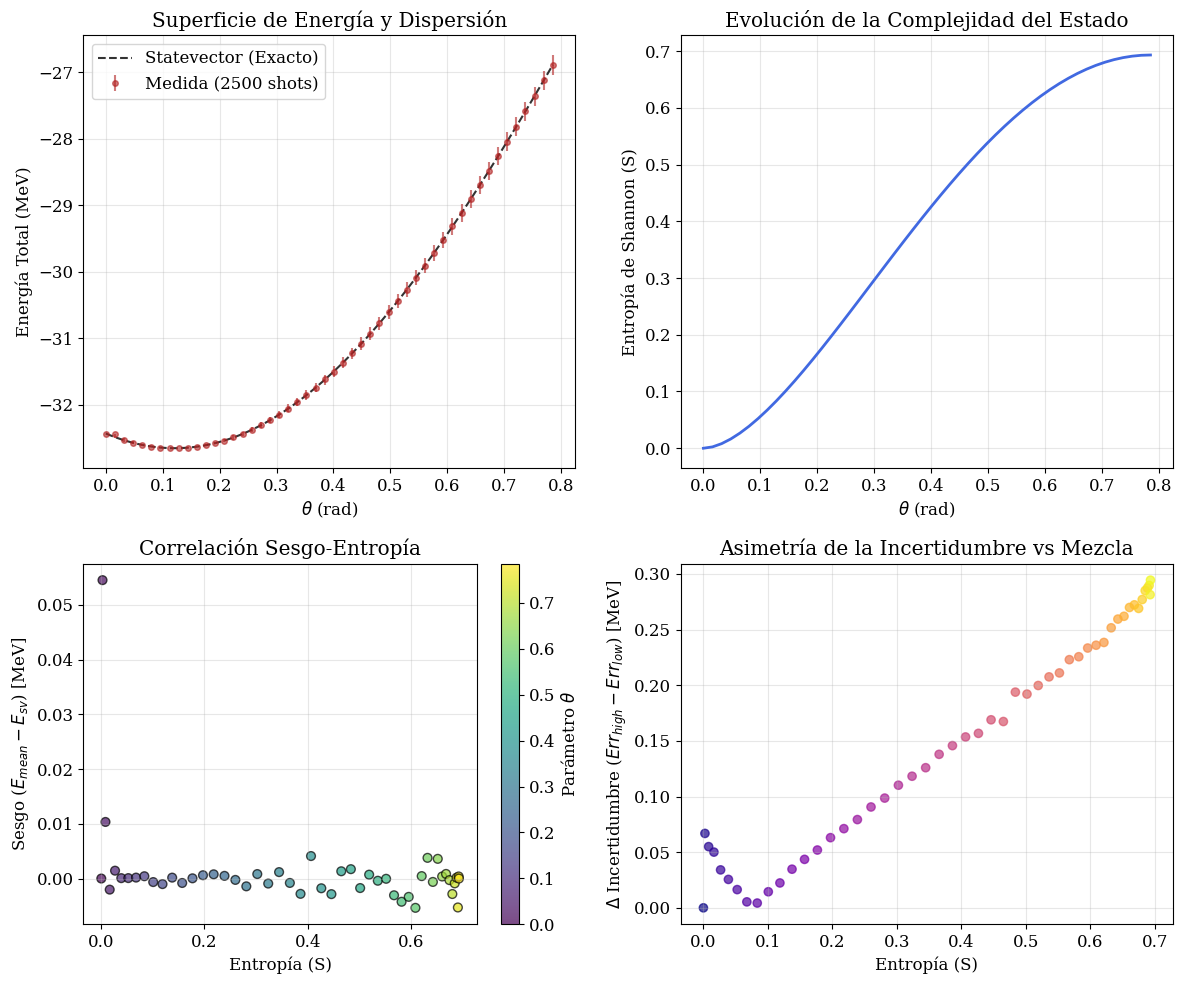

In [ ]:
plot_nuclear_analysis(np.linspace(0, np.pi/4, 50), res, 2500)